#  Churn Analytica — Data Mining & Prédiction du Churn Télécom
##  Pipeline End-to-End : De la Fusion de Données à la Recommandation Stratégique

---

###  Executive Summary
Ce projet présente une analyse rigoureuse du churn dans le secteur des télécommunications.  
Objectif double : **prédire** les départs clients et **prescrire** des actions de rétention personnalisées.

**Points clés :**
- **Ingénierie des données :** Fusion de 5 sources hétérogènes sur 7 043 clients.
- **Rigueur statistique :** Gini, Lorenz, Asymétrie, V de Cramér — justifiés et interprétés.
- **Robustesse ML :** Validation croisée 5-fold stratifiée + analyse du coût asymétrique des erreurs.
- **Interprétabilité :** Règles IF-THEN extraites par arbre de décision → plan d'action métier direct.
- **Déploiement :** Application Streamlit avec simulateur de risque et moteur de recommandation d'offres.

---

###  Sommaire
1. [Configuration & Setup](#setup)
2. [Ingestion & Fusion des 5 Sources](#fusion)
3. [Exploration Initiale](#exploration)
4. [Prétraitement & Feature Engineering](#preprocess)
5. [Feature Selection](#feature) — MI, RF Importance, Pearson, V de Cramér
6. [Analyse Descriptive](#stats) — Boxplots, Gini, Lorenz
7. [Réponses aux Questions Métier](#business)
8. [Data Mining Non-Supervisé](#unsupervised) — K-Means, DBSCAN, ACP
9. [Arbres de Décision & Règles Métier](#rules)
---

<a id='setup'></a>
---
## 1️) Configuration & Imports

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_validate, cross_val_score)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, f1_score, precision_score, recall_score)
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ── Paramètres globaux ────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.25
N_FOLDS      = 5

# ── Palette de couleurs cohérente ─────────────────────────────────────────────
CHURN_YES = '#e53935'   # Rouge  → Churner
CHURN_NO  = '#1565c0'   # Bleu   → Fidèle
LOYAL     = '#2e7d32'   # Vert   → Loyal/Positif
RISK      = '#f57f17'   # Orange → Risque

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.facecolor'    : '#f8f9fa',
    'figure.facecolor'  : 'white',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.dpi'        : 100,
})

print(" Configuration OK — random_state=42 partout pour reproductibilité totale")


 Configuration OK — random_state=42 partout pour reproductibilité totale


<a id='fusion'></a>
---
## 2️) Ingestion & Fusion des 5 Sources CSV

Les données client sont naturellement dispersées dans les systèmes d'information : CRM (démographie), SIG (localisation), facturation (services), comptabilité (statut) et données externes (population). La fusion progressive sur `CustomerID` reconstitue la vue client à 360°.

In [93]:
# ── Chargement des 5 sources ─────────────────────────────────────────────────
df_demo = pd.read_csv('/home/ahmed-bensalah/Downloads/final/Telecom_Demographie.csv')
df_loc  = pd.read_csv('/home/ahmed-bensalah/Downloads/final/Telecom_Localisation.csv')
df_svc  = pd.read_csv('/home/ahmed-bensalah/Downloads/final/Telecom_Services.csv')
df_pop  = pd.read_csv('/home/ahmed-bensalah/Downloads/final/Telecom_Population.csv')
df_stat = pd.read_csv('/home/ahmed-bensalah/Downloads/final/Telecom_Statut.csv')

for name, d in [('Démographie', df_demo), ('Localisation', df_loc),
                ('Services',    df_svc),  ('Population',   df_pop),
                ('Statut',      df_stat)]:
    print(f"  {name:15s}: {d.shape[0]:,} lignes × {d.shape[1]:2d} colonnes")

# ── Agrégation Population (éviter jointure M:N) ───────────────────────────────
df_pop_clean = df_pop.groupby('Zip Code', as_index=False)['Population'].mean()
print(f"\n  Population agrégée : {df_pop.shape[0]:,} → {df_pop_clean.shape[0]:,} codes postaux uniques")


  Démographie    : 7,043 lignes ×  6 colonnes
  Localisation   : 7,043 lignes ×  9 colonnes
  Services       : 7,043 lignes × 17 colonnes
  Population     : 7,043 lignes ×  3 colonnes
  Statut         : 7,043 lignes ×  9 colonnes

  Population agrégée : 7,043 → 1,652 codes postaux uniques


In [94]:
# ── Fusion progressive ───────────────────────────────────────────────────────
df = df_demo.merge(df_loc,       on='CustomerID', suffixes=('', '_loc'))
df = df.merge(df_svc,            on='CustomerID', suffixes=('', '_svc'))
df = df.merge(df_stat,           on='CustomerID', suffixes=('', '_stat'))
df = df.merge(df_pop_clean,      on='Zip Code',   how='left')

# Supprimer les colonnes Count dupliquées issues des fusions
count_cols = [c for c in df.columns if 'Count' in c and c != 'Count' and c != 'Country']
if count_cols:
    df.drop(columns=count_cols, inplace=True, errors='ignore')

# ── Vérification de qualité ────────────────────────────────────────────────────
print("RÉSULTAT DE LA FUSION")
print("=" * 55)
print(f"  Shape finale      : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"  CustomerID uniques: {df['CustomerID'].nunique():,}")
print(f"  Doublons          : {df.duplicated('CustomerID').sum()}")

if df['CustomerID'].nunique() == len(df):
    print("\n   SUCCÈS : 1 ligne = 1 client (pas de doublon)")
else:
    print("\n    ATTENTION : Des doublons sont présents !")

print(f"\n  Taux de Churn     : {df['Churn Value'].mean()*100:.1f}%")
df.head(3)


RÉSULTAT DE LA FUSION
  Shape finale      : 7,043 lignes × 36 colonnes
  CustomerID uniques: 7,043
  Doublons          : 0

   SUCCÈS : 1 ligne = 1 client (pas de doublon)

  Taux de Churn     : 26.5%


,CustomerID,Count,Gender,Senior Citizen,Partner,Dependents,Country,State,City,Zip Code,...,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Churn Score Category,CLTV Category,Population
0,3668-QPYBK,1,Male,No,No,No,United States,California,Los Angeles,90003,...,53.85,108.15,Yes,1,86,3239,Competitor made better offer,"(80, 90]","(3000, 3500]",10324.0
1,9237-HQITU,1,Female,No,No,Yes,United States,California,Los Angeles,90005,...,70.70,151.65,Yes,1,67,2701,Moved,"(60, 70]","(2500, 3000]",7445.8
2,9305-CDSKC,1,Female,No,No,Yes,United States,California,Los Angeles,90006,...,99.65,820.5,Yes,1,86,5372,Moved,"(80, 90]","(5000, 5500]",7447.2


<a id='exploration'></a>
---
## 3️) Exploration Initiale

**Objectif :** Comprendre la structure des données avant tout traitement. On inspecte les types, les valeurs manquantes et la distribution de la variable cible.

In [95]:
# ── Vue d'ensemble ───────────────────────────────────────────────────────────
print(f"Dataset : {len(df):,} clients × {df.shape[1]} variables")
print(f"Churn   : {df['Churn Value'].sum():,} churners ({df['Churn Value'].mean()*100:.1f}%)")
print(f"Fidèles : {(df['Churn Value']==0).sum():,} fidèles ({(df['Churn Value']==0).mean()*100:.1f}%)")
print("\nTypes de variables :")
print(df.dtypes.value_counts().to_string())


Dataset : 7,043 clients × 36 variables
Churn   : 1,869 churners (26.5%)
Fidèles : 5,174 fidèles (73.5%)

Types de variables :
str        26
int64       6
float64     4


In [96]:
# ── Variables manquantes ─────────────────────────────────────────────────────
nan_counts = df.isnull().sum()
nan_pct    = (df.isnull().mean() * 100).round(2)
nan_df     = pd.DataFrame({'NaN Count': nan_counts, 'NaN %': nan_pct})
nan_df     = nan_df[nan_df['NaN Count'] > 0].sort_values('NaN Count', ascending=False)

if nan_df.empty:
    print(" Aucune valeur manquante détectée (hors Churn Reason normale)")
else:
    print("Colonnes avec valeurs manquantes :")
    display(nan_df)


Colonnes avec valeurs manquantes :


,NaN Count,NaN %
Churn Reason,5174,73.46


In [97]:
# Vérifier répartition
df.groupby('Churn Value')['Churn Reason'].apply(lambda x: x.isna().sum())

Churn Value
0    5174
1       0
Name: Churn Reason, dtype: int64

Churn Reason : Cette colonne est vide pour les clients fidèles *par construction* — un client qui ne part pas n'a pas de raison de départ. Ce ne sont **pas** des valeurs manquantes à imputer.


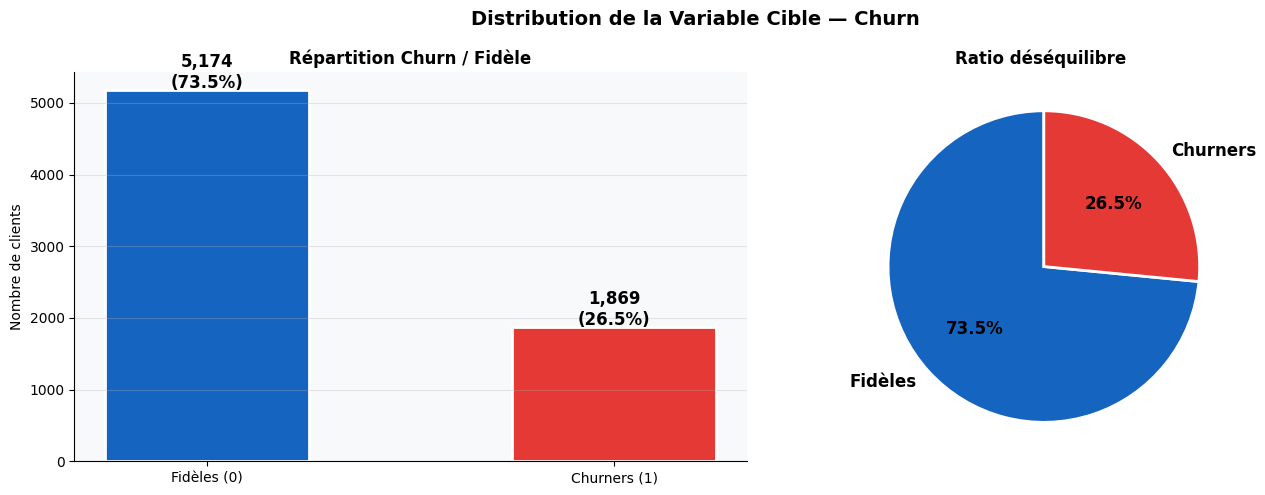

In [98]:
# ── Distribution de la variable cible ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution de la Variable Cible — Churn', fontsize=14, fontweight='bold')

# Barplot
counts = df['Churn Value'].value_counts()
colors = [CHURN_NO, CHURN_YES]
bars   = axes[0].bar(['Fidèles (0)', 'Churners (1)'], counts.values,
                     color=colors, edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Répartition Churn / Fidèle', fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(counts.values, labels=['Fidèles', 'Churners'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title(f'Ratio déséquilibre ', fontweight='bold')


plt.tight_layout()
plt.show()

<a id='preprocess'></a>
---
## 4️⃣ Prétraitement & Feature Engineering

| Variable supprimée | Raison |
|---|---|
| `CustomerID` | Identifiant unique → risque de data leakage |
| `Count`, `Country` | Constante → aucune variance, zéro information |
| `Lat Long` | Redondant avec `Latitude` et `Longitude` séparées |
| `Churn Label` | Doublon texte de `Churn Value` → **data leakage** |
| `Churn Score`, `Churn Score Category` | Calculé après le churn → **data leakage** |
| `Churn Reason` | Disponible seulement post-départ → **data leakage** |
| `CLTV Category` | Discrétisation de `CLTV` → redondant, perte d'info |


In [99]:
# ── ÉTAPE 1 : Correction de Total Charges (object → float) ──────────────────
# Problème : Total Charges contient des espaces vides pour Tenure=0
# Solution : conversion forcée, NaN imputés par Monthly × Tenure

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
imputed = df['Total Charges'].isna().sum()
df['Total Charges'] = df['Total Charges'].fillna(df['Monthly Charges'] * df['Tenure Months'])

print(f"   Type final : {df['Total Charges'].dtype}")


   Type final : float64


In [100]:
# ── ÉTAPE 2 : Suppression justifiée des colonnes ──────────────────────────────
drop_cols = [
    'Count',                  # Constante (= 1 partout)
    'Country',                # Constante (un seul pays)
    'Lat Long',               # Redondant avec Latitude/Longitude
    'CustomerID',                     # Identifiant → data leakage
    'Churn Label',            # Doublon texte de Churn Value → data leakage
    'Churn Score',            # Calculé post-churn → data leakage
    'Churn Score Category',   # Discrétisation de Churn Score → redondant
    'Churn Reason',           # Disponible seulement après départ → data leakage
    'CLTV Category',          # Discrétisation de CLTV → redondant
]

shape_avant = df.shape
df.drop(columns=drop_cols, errors='ignore', inplace=True)
shape_apres = df.shape

supprimees = [c for c in drop_cols if c not in df.columns or shape_avant[1] != shape_apres[1]]
print(f"✅ Suppression terminée")
print(f"   Shape avant : {shape_avant[0]:,} × {shape_avant[1]}")
print(f"   Shape après : {shape_apres[0]:,} × {shape_apres[1]}")
print(f"   Colonnes supprimées : {shape_avant[1] - shape_apres[1]}")


✅ Suppression terminée
   Shape avant : 7,043 × 36
   Shape après : 7,043 × 27
   Colonnes supprimées : 9


In [101]:
# ── ÉTAPE 3 : Feature Engineering (Variables dérivées) ───────────────────────
# Ces nouvelles variables capturent des effets non-linéaires importants

# 1. Groupes d'ancienneté → capture l'effet "cycle de vie client"
df['Tenure Group'] = pd.cut(
    df['Tenure Months'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1 an', '1-2 ans', '2-4 ans', '4-6 ans']
)

# 2. Groupes de charges mensuelles → capture les niveaux de prix
df['Charge Group'] = pd.cut(
    df['Monthly Charges'],
    bins=[0, 35, 60, 90, 120],
    labels=['< 35$', '35-60$', '60-90$', '> 90$']
)

# 3. Nombre de services souscrits → mesure de l'engagement client
service_cols = ['Online Security', 'Online Backup', 'Device Protection',
                'Tech Support', 'Streaming TV', 'Streaming Movies']
df['N Services'] = df[service_cols].apply(lambda r: (r == 'Yes').sum(), axis=1)

print(" Variables dérivées créées :")
print(f"   Tenure Group  : {df['Tenure Group'].value_counts().to_dict()}")
print(f"   Charge Group  : {df['Charge Group'].value_counts().to_dict()}")
print(f"   N Services    : de {df['N Services'].min()} à {df['N Services'].max()} services")
print(f"\n   Shape finale  : {df.shape[0]:,} × {df.shape[1]} variables")


 Variables dérivées créées :
   Tenure Group  : {'4-6 ans': 2239, '0-1 an': 2175, '2-4 ans': 1594, '1-2 ans': 1024}
   Charge Group  : {'60-90$': 2386, '> 90$': 1739, '< 35$': 1735, '35-60$': 1183}
   N Services    : de 0 à 6 services

   Shape finale  : 7,043 × 30 variables


<a id='feature'></a>
---
## 5️⃣ Feature Selection — Relations entre Variables

**Deux approches complémentaires :**

1. **Mutual Information (MI)** : mesure la dépendance statistique entre chaque variable et la cible, y compris les relations **non-linéaires**. Score MI > 0 = variable informative.

2. **Random Forest Importance** : mesure la contribution moyenne de chaque variable à la réduction d'impureté des arbres. Capture les **interactions** entre variables.

**Règle de sélection :** Une variable est conservée si MI > 0.02 **OU** RF Importance > 0.01. Cette double condition évite de supprimer des variables importantes détectées par un seul critère.

In [102]:
# ── Encodage Label pour le calcul des importances ────────────────────────────
df_enc = df.copy()
le     = LabelEncoder()
for col in df_enc.select_dtypes('object').columns:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

# Préparer X, y
X_fs = df_enc.drop('Churn Value', axis=1).select_dtypes(include=np.number)
y_fs = df_enc['Churn Value']

print(f" Encodage terminé : {X_fs.shape[1]} variables numériques prêtes")
print(f"   Classes cible : {y_fs.value_counts().to_dict()}")


 Encodage terminé : 27 variables numériques prêtes
   Classes cible : {0: 5174, 1: 1869}


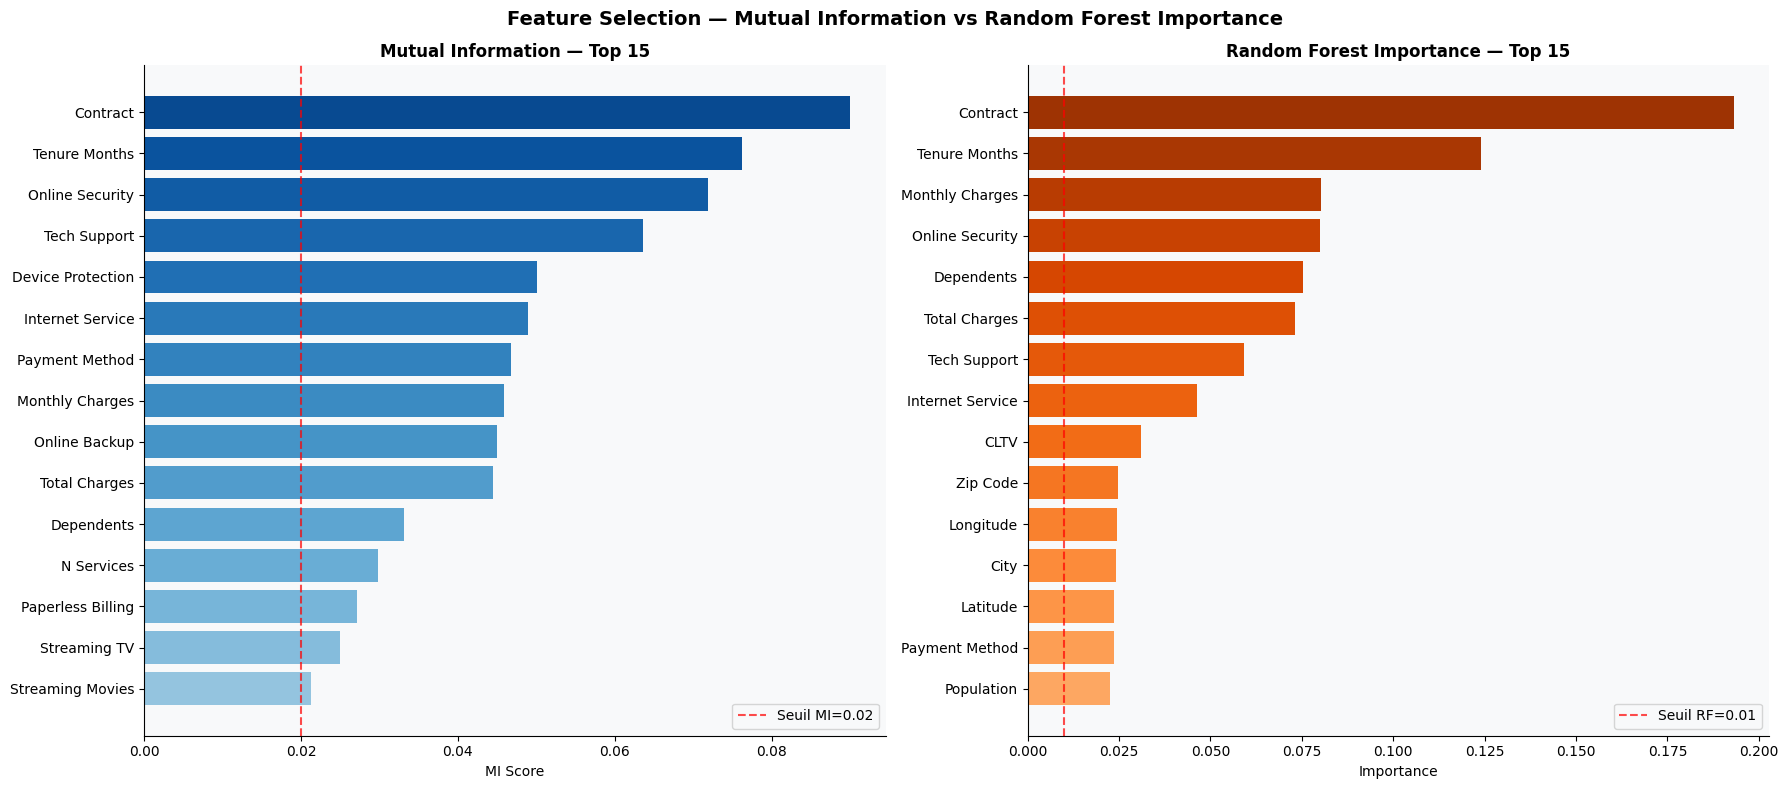


 Variables sélectionnées (MI>0.02 OU RF>0.01) : 21
   Top 5 : ['Contract', 'Tenure Months', 'Monthly Charges', 'Online Security', 'Dependents']


In [103]:
# ── Mutual Information ───────────────────────────────────────────────────────
mi_scores = mutual_info_classif(X_fs, y_fs, random_state=RANDOM_STATE)
mi_df     = pd.DataFrame({'Variable': X_fs.columns, 'MI Score': mi_scores})
mi_df     = mi_df.sort_values('MI Score', ascending=False).reset_index(drop=True)

# ── Random Forest Importance ─────────────────────────────────────────────────
rf_temp   = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=RANDOM_STATE,
                                    class_weight='balanced')
rf_temp.fit(X_fs, y_fs)
rf_imp    = pd.DataFrame({'Variable': X_fs.columns, 'RF Importance': rf_temp.feature_importances_})
rf_imp    = rf_imp.sort_values('RF Importance', ascending=False).reset_index(drop=True)

# ── Visualisation côte à côte ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Selection — Mutual Information vs Random Forest Importance',
             fontsize=14, fontweight='bold')

# MI plot
top_mi = mi_df.head(15)
axes[0].barh(top_mi['Variable'][::-1], top_mi['MI Score'][::-1],
             color=plt.cm.Blues(np.linspace(0.4, 0.9, 15)))
axes[0].axvline(0.02, color='red', linestyle='--', alpha=0.7, label='Seuil MI=0.02')
axes[0].set_title('Mutual Information — Top 15', fontweight='bold')
axes[0].set_xlabel('MI Score')
axes[0].legend()

# RF plot
top_rf = rf_imp.head(15)
axes[1].barh(top_rf['Variable'][::-1], top_rf['RF Importance'][::-1],
             color=plt.cm.Oranges(np.linspace(0.4, 0.9, 15)))
axes[1].axvline(0.01, color='red', linestyle='--', alpha=0.7, label='Seuil RF=0.01')
axes[1].set_title('Random Forest Importance — Top 15', fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].legend()

plt.tight_layout()
plt.show()

# Variables sélectionnées
important_vars = set(mi_df[mi_df['MI Score'] > 0.02]['Variable']) |                  set(rf_imp[rf_imp['RF Importance'] > 0.01]['Variable'])
print(f"\n Variables sélectionnées (MI>0.02 OU RF>0.01) : {len(important_vars)}")
print(f"   Top 5 : {list(rf_imp.head(5)['Variable'])}")


###  Analyse Bivariée : Corrélation de Pearson & V de Cramér

**Pearson** pour les relations entre variables **numériques**.  
**V de Cramér** (basé sur χ²) pour les relations entre variables **catégorielles**.  
Ces deux analyses permettent de détecter les redondances et les liaisons fortes avec la cible.


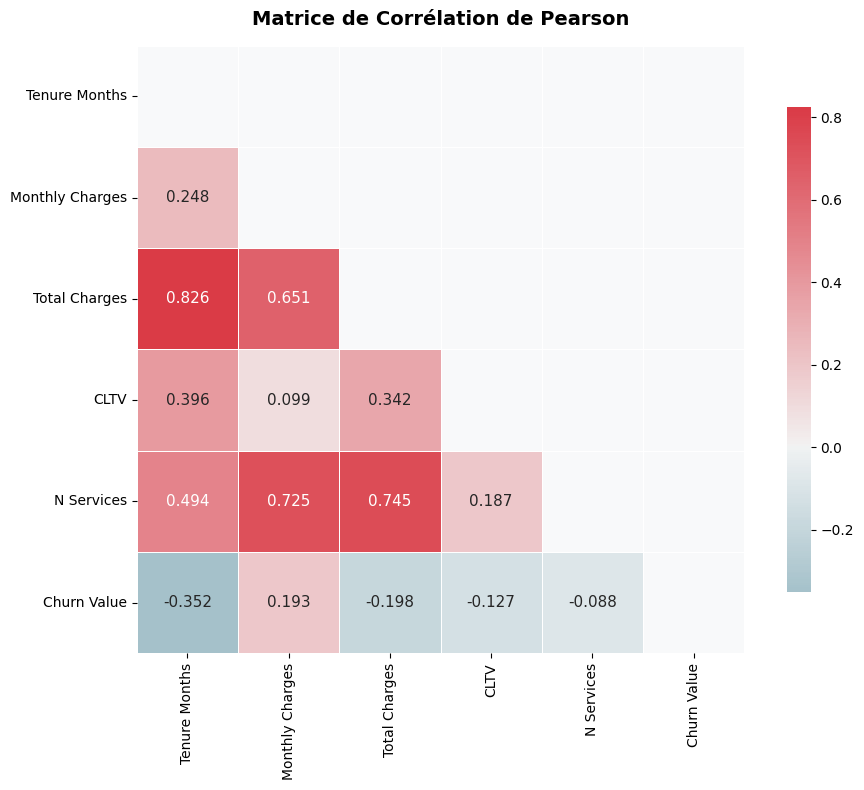

 Corrélations avec Churn Value :
  • Tenure Months: r=-0.352 → liaison modérée négative
  • Total Charges: r=-0.198 → liaison faible négative
  • Monthly Charges: r=0.193 → liaison faible positive
  • CLTV: r=-0.127 → liaison faible négative
  • N Services: r=-0.088 → liaison négligeable négative


In [104]:
# ── Corrélation de Pearson ────────────────────────────────────────────────────
num_vars  = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'N Services', 'Churn Value']
corr_mat  = df[num_vars].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
mask    = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask,
            cmap=sns.diverging_palette(220, 10, as_cmap=True), center=0,
            annot=True, fmt='.3f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 11})
ax.set_title('Matrice de Corrélation de Pearson', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(" Corrélations avec Churn Value :")
churn_corr = corr_mat['Churn Value'].drop('Churn Value').sort_values(key=abs, ascending=False)
for var, r in churn_corr.items():
    if   abs(r) > 0.5: force = "forte"
    elif abs(r) > 0.3: force = "modérée"
    elif abs(r) > 0.1: force = "faible"
    else:              force = "négligeable"
    sens = "positive" if r > 0 else "négative"
    print(f"  • {var}: r={r:.3f} → liaison {force} {sens}")


Le **V de Cramér** mesure l'intensité de la liaison entre deux variables qualitatives (0 = aucun lien, 1 = lien parfait). Basé sur le χ² normalisé.

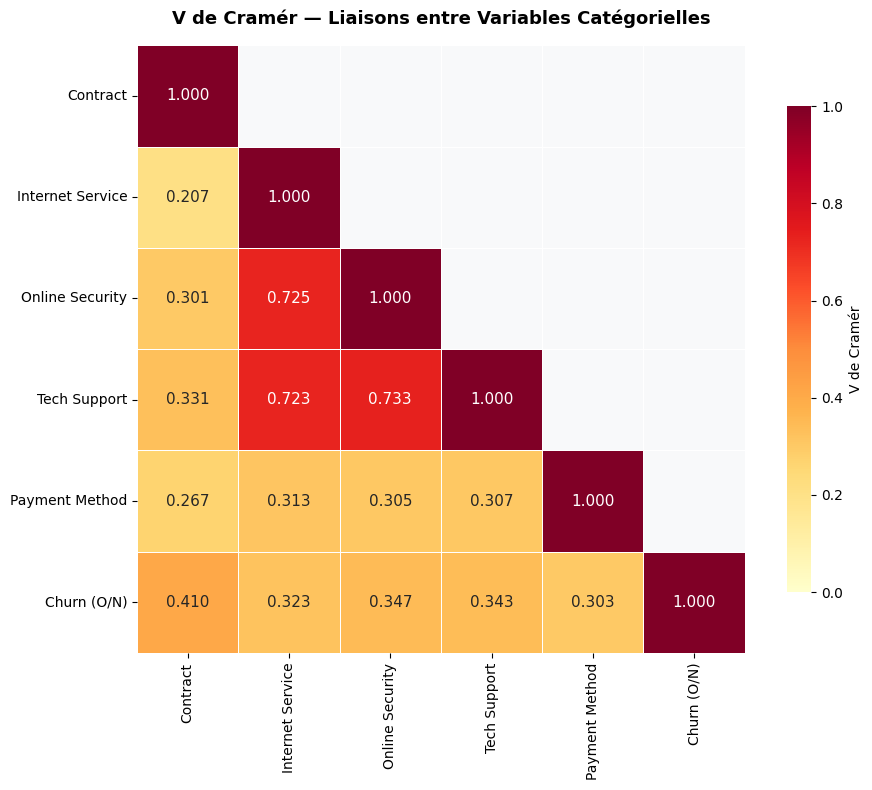

 Liaisons avec le Churn (V de Cramér) :
  • Contract            : V=0.410 → liaison forte ( p<0.001)
  • Online Security     : V=0.347 → liaison forte ( p<0.001)
  • Tech Support        : V=0.343 → liaison forte ( p<0.001)
  • Internet Service    : V=0.323 → liaison forte ( p<0.001)
  • Payment Method      : V=0.303 → liaison forte ( p<0.001)


In [105]:
# ── V de Cramér ──────────────────────────────────────────────────────────────
def cramers_v(col1, col2, data):
    ct   = pd.crosstab(data[col1], data[col2])
    chi2, p, dof, _ = chi2_contingency(ct)
    n    = ct.values.sum()
    v    = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    return round(v, 4), round(p, 6)

df_cr = df.copy()
df_cr['Churn (O/N)'] = df_cr['Churn Value'].map({0: 'Fidèle', 1: 'Churned'})

cat_vars = ['Contract', 'Internet Service', 'Online Security',
            'Tech Support', 'Payment Method', 'Churn (O/N)']

v_matrix = pd.DataFrame(index=cat_vars, columns=cat_vars, dtype=float)
p_matrix = pd.DataFrame(index=cat_vars, columns=cat_vars, dtype=float)
for v1 in cat_vars:
    for v2 in cat_vars:
        if v1 == v2:
            v_matrix.loc[v1, v2] = 1.0; p_matrix.loc[v1, v2] = 0.0
        else:
            v, p = cramers_v(v1, v2, df_cr)
            v_matrix.loc[v1, v2] = v; p_matrix.loc[v1, v2] = p

fig, ax = plt.subplots(figsize=(10, 8))
mask_up = np.triu(np.ones_like(v_matrix, dtype=bool), k=1)
sns.heatmap(v_matrix.astype(float), mask=mask_up,
            cmap='YlOrRd', vmin=0, vmax=1,
            annot=True, fmt='.3f', square=True, linewidths=0.5,
            cbar_kws={'label': 'V de Cramér', 'shrink': 0.8}, ax=ax,
            annot_kws={'size': 11})
ax.set_title('V de Cramér — Liaisons entre Variables Catégorielles', fontsize=13,
             fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(" Liaisons avec le Churn (V de Cramér) :")
churn_v = v_matrix.loc['Churn (O/N)'].drop('Churn (O/N)').sort_values(ascending=False)
for var, v in churn_v.items():
    p = p_matrix.loc['Churn (O/N)', var]
    force = 'très forte' if v > 0.5 else ('forte' if v > 0.3 else ('modérée' if v > 0.15 else 'faible'))
    sig   = ' p<0.001' if p < 0.001 else f'p={p:.4f}'
    print(f"  • {var:20s}: V={v:.3f} → liaison {force} ({sig})")


<a id='stats'></a>
---
## 6️) Analyse Descriptive Complète

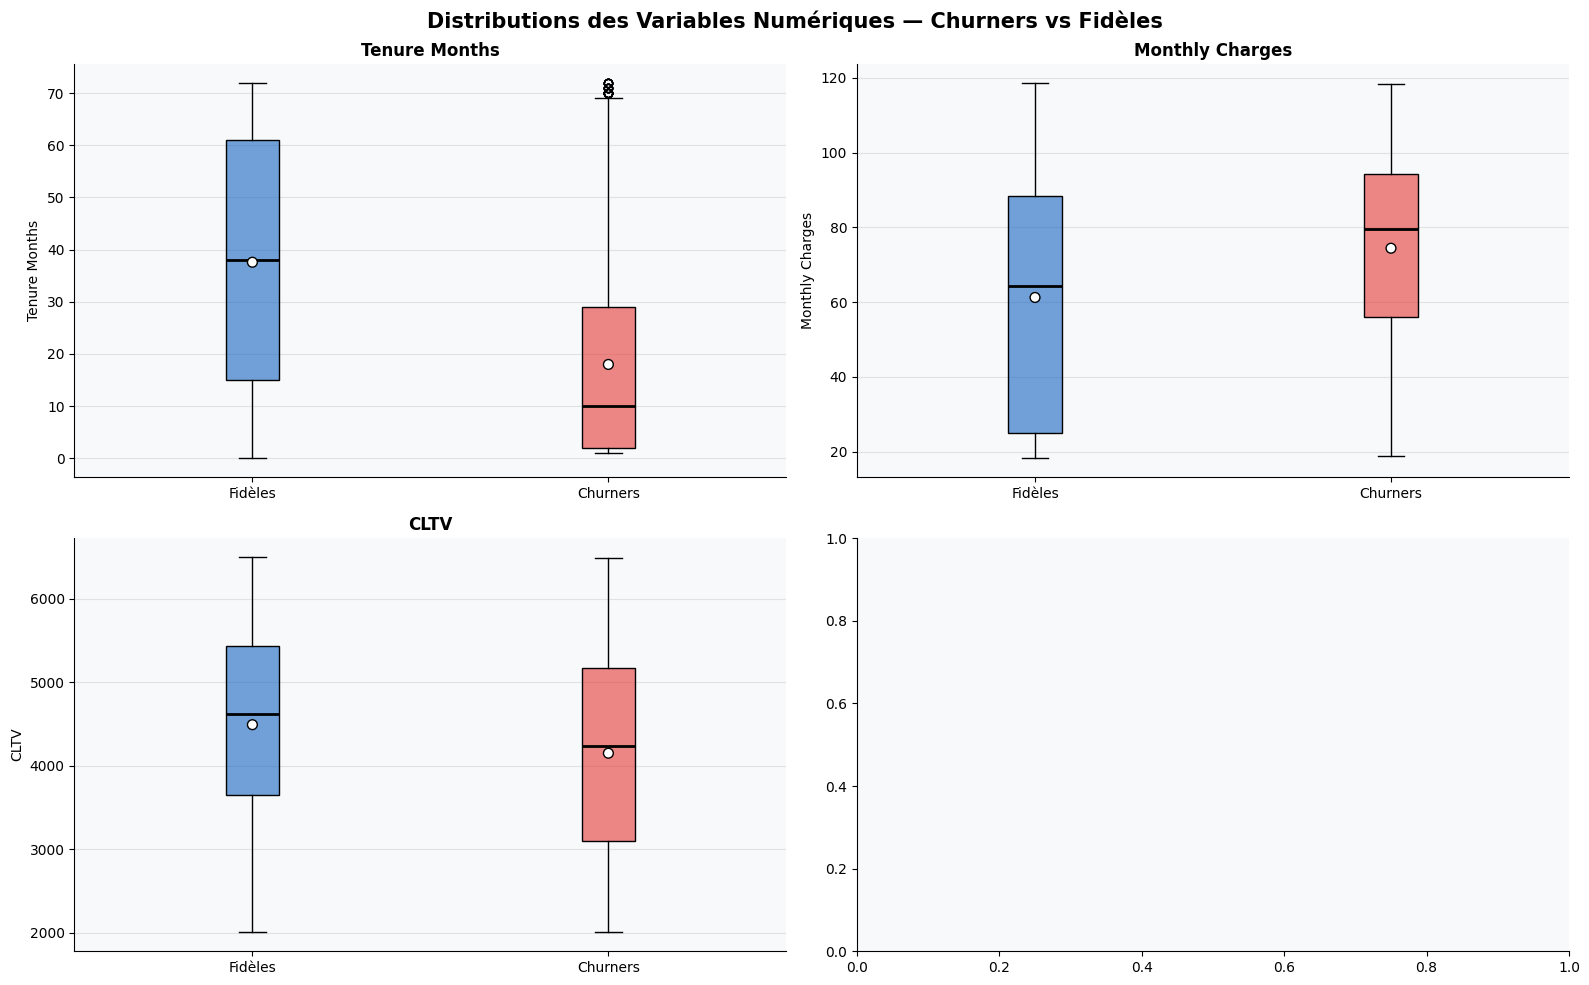

 Interprétations :
  • Tenure Months : les churners ont une ancienneté médiane très inférieure aux fidèles
  • Monthly Charges : les churners paient en moyenne plus cher
  • CLTV : les churners ont une valeur vie client plus faible


In [106]:
# ── Boxplots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distributions des Variables Numériques — Churners vs Fidèles',
             fontsize=15, fontweight='bold')

for ax, col in zip(axes.flat, ['Tenure Months', 'Monthly Charges', 'CLTV']):
    data = [pd.to_numeric(df[df['Churn Value']==0][col], errors='coerce').dropna(),
            pd.to_numeric(df[df['Churn Value']==1][col], errors='coerce').dropna()]
    bp   = ax.boxplot(data, labels=['Fidèles', 'Churners'], patch_artist=True,
                      medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor(CHURN_NO + '99')
    bp['boxes'][1].set_facecolor(CHURN_YES + '99')

    means = [d.mean() for d in data]
    ax.scatter([1, 2], means, color=['white', 'white'], zorder=5, s=50, edgecolors='black')
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.set_ylabel(col)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(" Interprétations :")
print("  • Tenure Months : les churners ont une ancienneté médiane très inférieure aux fidèles")
print("  • Monthly Charges : les churners paient en moyenne plus cher")
print("  • CLTV : les churners ont une valeur vie client plus faible")


In [107]:
# ── Asymétrie (Skewness) & Aplatissement (Kurtosis) ─────────────────────────
from scipy.stats import skew, kurtosis

shape_stats = []
for col in ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'N Services']:
    s   = df[col].dropna()
    sk  = skew(s)
    ku  = kurtosis(s)
    cv  = (s.std() / s.mean() * 100) if s.mean() != 0 else 0
    skew_interp = 'forte droite' if sk > 1 else ('légère droite' if sk > 0.3
                  else ('forte gauche' if sk < -1 else ('légère gauche' if sk < -0.3 else 'symétrique')))
    shape_stats.append({'Variable': col, 'Skewness': round(sk, 3), 'Interprétation': skew_interp,
                        'Kurtosis': round(ku, 3), 'CV (%)': round(cv, 1)})

shape_df = pd.DataFrame(shape_stats)
display(shape_df)




,Variable,Skewness,Interprétation,Kurtosis,CV (%)
0,Tenure Months,0.239,symétrique,-1.387,75.9
1,Monthly Charges,-0.220,symétrique,-1.257,46.5
2,Total Charges,0.963,légère droite,-0.229,99.4
3,CLTV,-0.312,légère gauche,-0.934,26.9
4,N Services,0.452,légère droite,-0.966,90.7


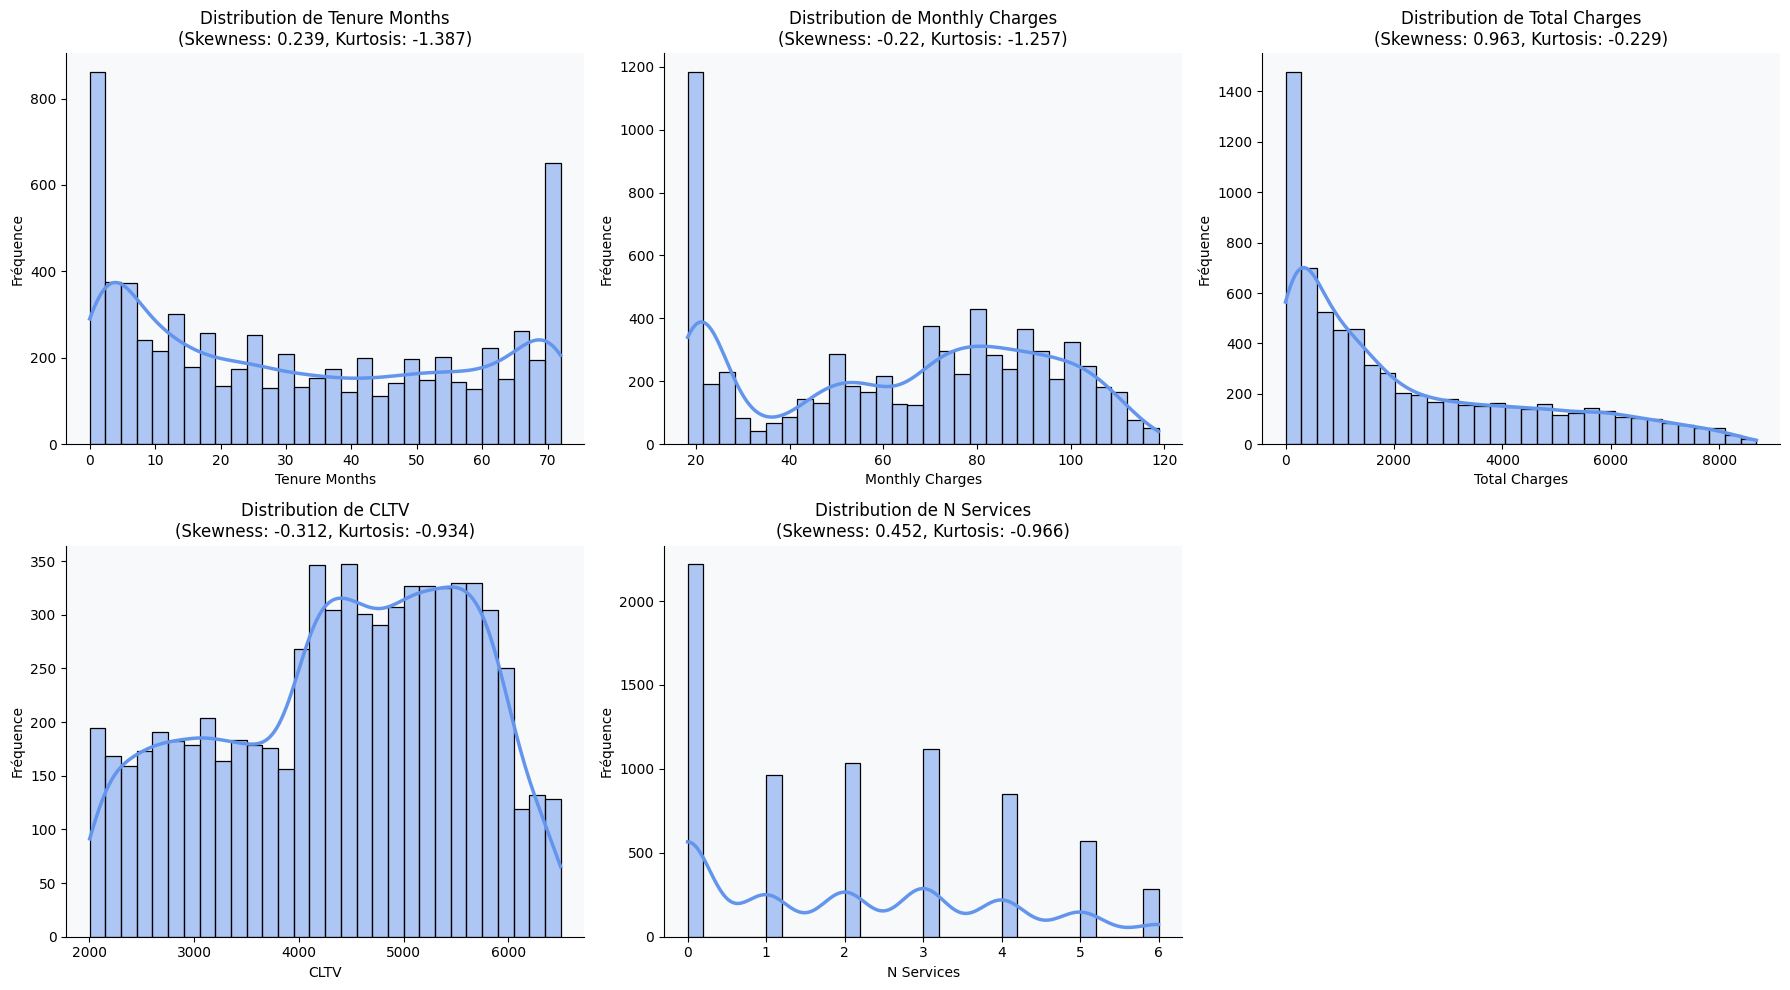

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'N Services']

# Création d'une figure avec 2 lignes et 3 colonnes
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    # KDE line with crimson color
    sns.histplot(
        df[col].dropna(), 
        kde=True, 
        ax=axes[i], 
        color='cornflowerblue', 
        bins=30,
        line_kws={'color': 'crimson', 'linewidth': 2.5}
    )
    
    sk = shape_df[shape_df['Variable'] == col]['Skewness'].values[0]
    ku = shape_df[shape_df['Variable'] == col]['Kurtosis'].values[0]
    axes[i].set_title(f'Distribution de {col}\n(Skewness: {sk}, Kurtosis: {ku})', fontsize=12)
    axes[i].set_ylabel('Fréquence')

# Supprimer le 6ème graphique vide
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


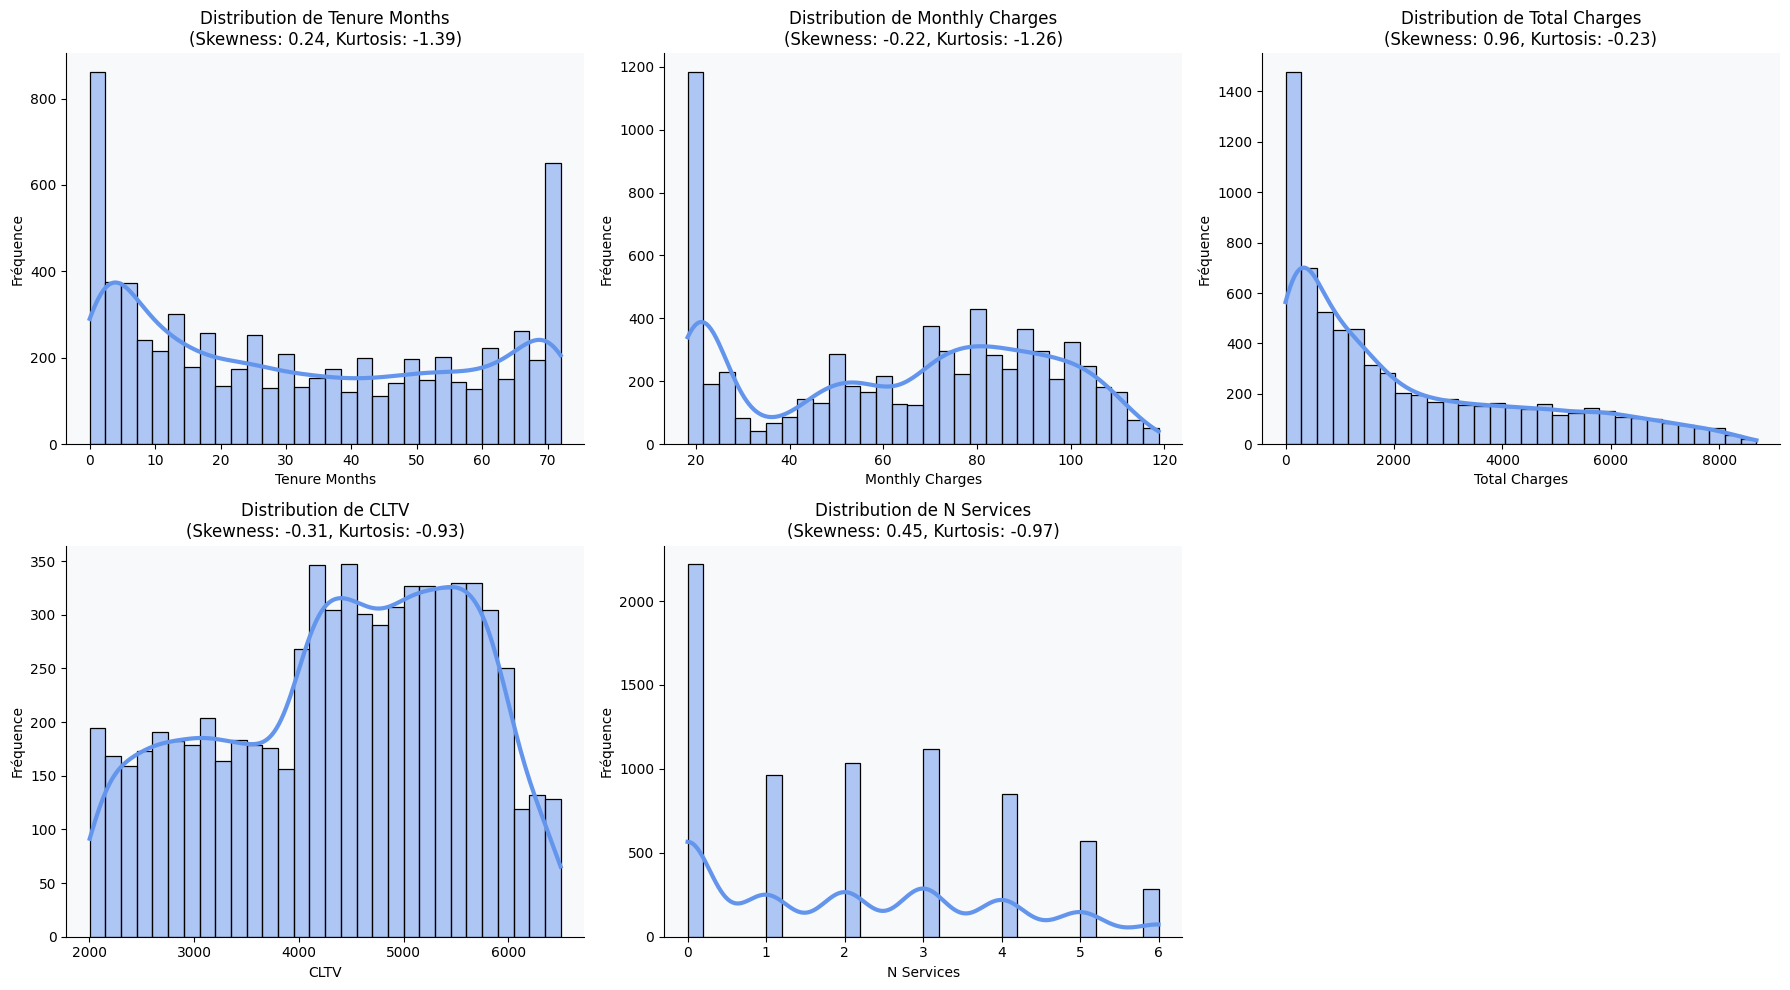

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'N Services']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(
        df[col].dropna(), 
        kde=True, 
        ax=axes[i], 
        color='cornflowerblue',  # Couleur de l'histogramme
        bins=30,
        # line_kws est le bon argument ici pour la ligne du KDE
        line_kws={'color': 'darkorange', 'linewidth': 3}
    )
    
    sk = shape_df[shape_df['Variable'] == col]['Skewness'].values[0]
    ku = shape_df[shape_df['Variable'] == col]['Kurtosis'].values[0]
    
    axes[i].set_title(f'Distribution de {col}\n(Skewness: {sk:.2f}, Kurtosis: {ku:.2f})', fontsize=12)
    axes[i].set_ylabel('Fréquence')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### Concentration : Courbe de Lorenz & Indice de Gini

La **courbe de Lorenz** visualise les inégalités dans la distribution d'une variable.  
L'**indice de Gini** les quantifie (0 = égalité parfaite, 1 = concentration totale).  



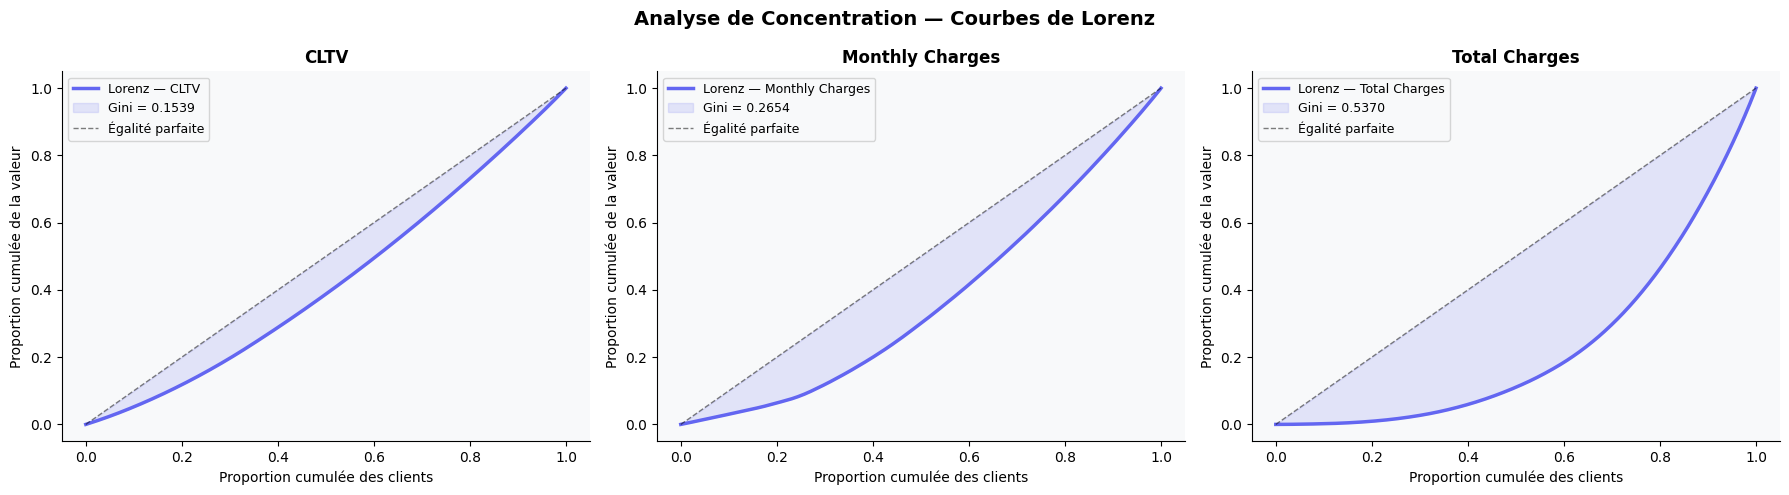


 Indices de Gini :
  • CLTV                : Gini=0.1539 → concentration faible
  • Monthly Charges     : Gini=0.2654 → concentration faible
  • Total Charges       : Gini=0.5370 → concentration forte


In [110]:
# ── Gini & Lorenz ─────────────────────────────────────────────────────────────
def gini_lorenz(series, label, ax):
    s      = np.sort(series.dropna())
    n      = len(s)
    cumsum = np.cumsum(s)
    lorenz = cumsum / cumsum[-1]
    lorenz = np.concatenate([[0], lorenz])
    x      = np.linspace(0, 1, n + 1)
    gini = 1 - 2 * np.trapezoid(lorenz, x)
    ax.plot(x, lorenz, color='#6366f1', lw=2.5, label=f'Lorenz — {label}')
    ax.fill_between(x, lorenz, x, alpha=0.15, color='#6366f1', label=f'Gini = {gini:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Égalité parfaite')
    ax.set_xlabel('Proportion cumulée des clients')
    ax.set_ylabel('Proportion cumulée de la valeur')
    ax.legend(fontsize=9)
    return gini

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analyse de Concentration — Courbes de Lorenz', fontsize=14, fontweight='bold')

gini_scores = {}
for ax, col in zip(axes, ['CLTV', 'Monthly Charges', 'Total Charges']):
    g = gini_lorenz(df[col], col, ax)
    ax.set_title(col, fontweight='bold')
    gini_scores[col] = g

plt.tight_layout()
plt.show()

print("\n Indices de Gini :")
for col, g in gini_scores.items():
    niveau = 'forte' if g > 0.5 else ('modérée' if g > 0.3 else 'faible')
    print(f"  • {col:20s}: Gini={g:.4f} → concentration {niveau}")


<a id='business'></a>
---
## 7️) Réponses aux Questions Métier

### Q1 — Quels facteurs influencent le plus le churn ?


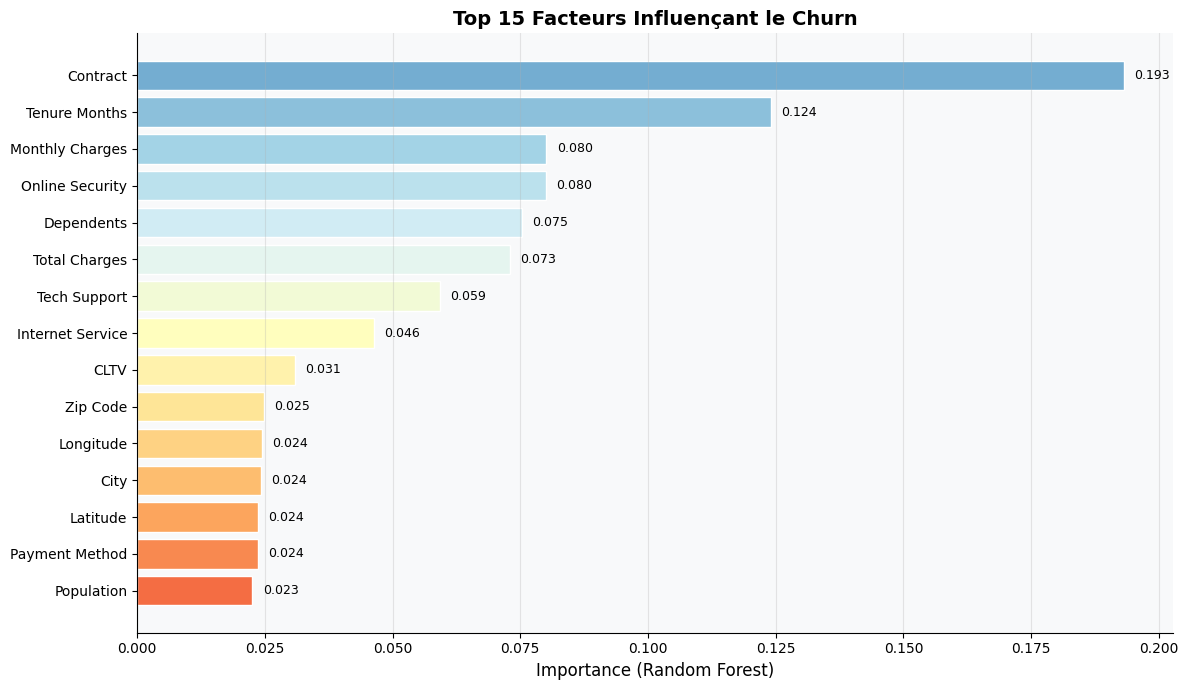

 Top 5 facteurs décisifs :
  • Contract                 : importance = 0.1931
  • Tenure Months            : importance = 0.1241
  • Monthly Charges          : importance = 0.0801
  • Online Security          : importance = 0.0799
  • Dependents               : importance = 0.0753


In [111]:
# ── Top facteurs (Feature Importance) ───────────────────────────────────────
top15 = rf_imp.head(15)
fig, ax = plt.subplots(figsize=(12, 7))
colors  = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(top15)))
bars    = ax.barh(top15['Variable'][::-1], top15['RF Importance'][::-1],
                  color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, top15['RF Importance'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Importance (Random Forest)', fontsize=12)
ax.set_title('Top 15 Facteurs Influençant le Churn', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(" Top 5 facteurs décisifs :")
for _, row in top15.head(5).iterrows():
    print(f"  • {row['Variable']:25s}: importance = {row['RF Importance']:.4f}")


### Q2 — Le type de contrat est-il le facteur de rétention le plus puissant ?

Cette question est au cœur du churn télécom. Un contrat mensuel laisse le client libre de partir à tout moment.


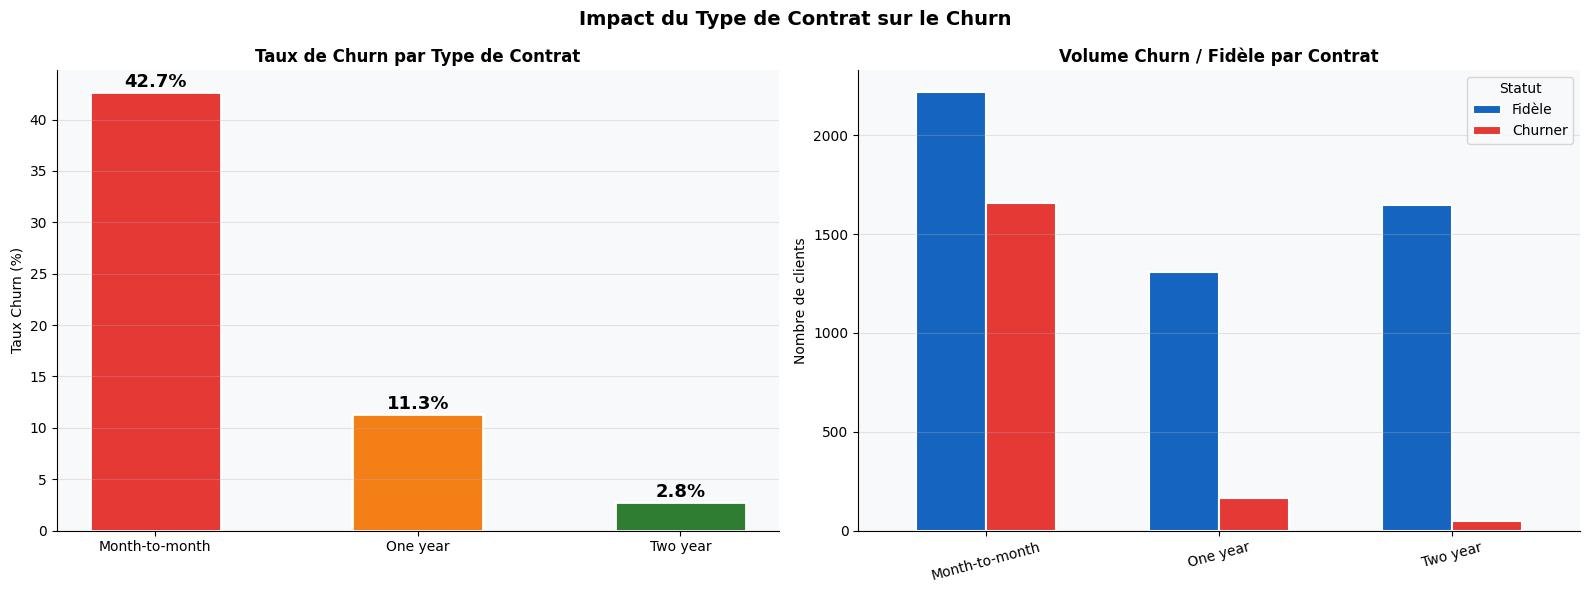

,Taux Churn,Nb Churners,Nb Clients,Taux Churn %
Contract,,,,
Month-to-month,0.427097,1655,3875,42.7
One year,0.112695,166,1473,11.3
Two year,0.028319,48,1695,2.8


In [112]:
# ── Taux de churn par type de contrat ────────────────────────────────k────────
contract_churn = df.groupby('Contract')['Churn Value'].agg(['mean', 'sum', 'count'])
contract_churn.columns = ['Taux Churn', 'Nb Churners', 'Nb Clients']
contract_churn['Taux Churn %'] = (contract_churn['Taux Churn'] * 100).round(1)
contract_churn = contract_churn.sort_values('Taux Churn', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Impact du Type de Contrat sur le Churn', fontsize=14, fontweight='bold')

# Barplot taux de churn
colors_c = [CHURN_YES if t > 0.3 else (RISK if t > 0.1 else LOYAL)
            for t in contract_churn['Taux Churn']]
bars = axes[0].bar(contract_churn.index, contract_churn['Taux Churn %'],
                   color=colors_c, edgecolor='white', linewidth=2, width=0.5)
for bar, pct in zip(bars, contract_churn['Taux Churn %']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{pct}%', ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Taux de Churn par Type de Contrat', fontweight='bold')
axes[0].set_ylabel('Taux Churn (%)')
axes[0].grid(axis='y', alpha=0.3)

# Composition Churn/Fidèle
stacked = df.groupby(['Contract', 'Churn Value']).size().unstack(fill_value=0)
stacked.plot(kind='bar', ax=axes[1], color=[CHURN_NO, CHURN_YES],
             edgecolor='white', linewidth=1.5, width=0.6)
axes[1].set_title('Volume Churn / Fidèle par Contrat', fontweight='bold')
axes[1].set_ylabel('Nombre de clients')
axes[1].set_xlabel('')
axes[1].legend(['Fidèle', 'Churner'], title='Statut')
axes[1].grid(axis='y', alpha=0.3)
plt.setp(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

display(contract_churn)


Conclusion : le contrat Mois-à-Mois a un taux de churn plus élevé

Action : incentiver la migration vers des contrats annuels ou bi-annuels.


### Q3 — Quels services protègent le mieux contre le churn ?


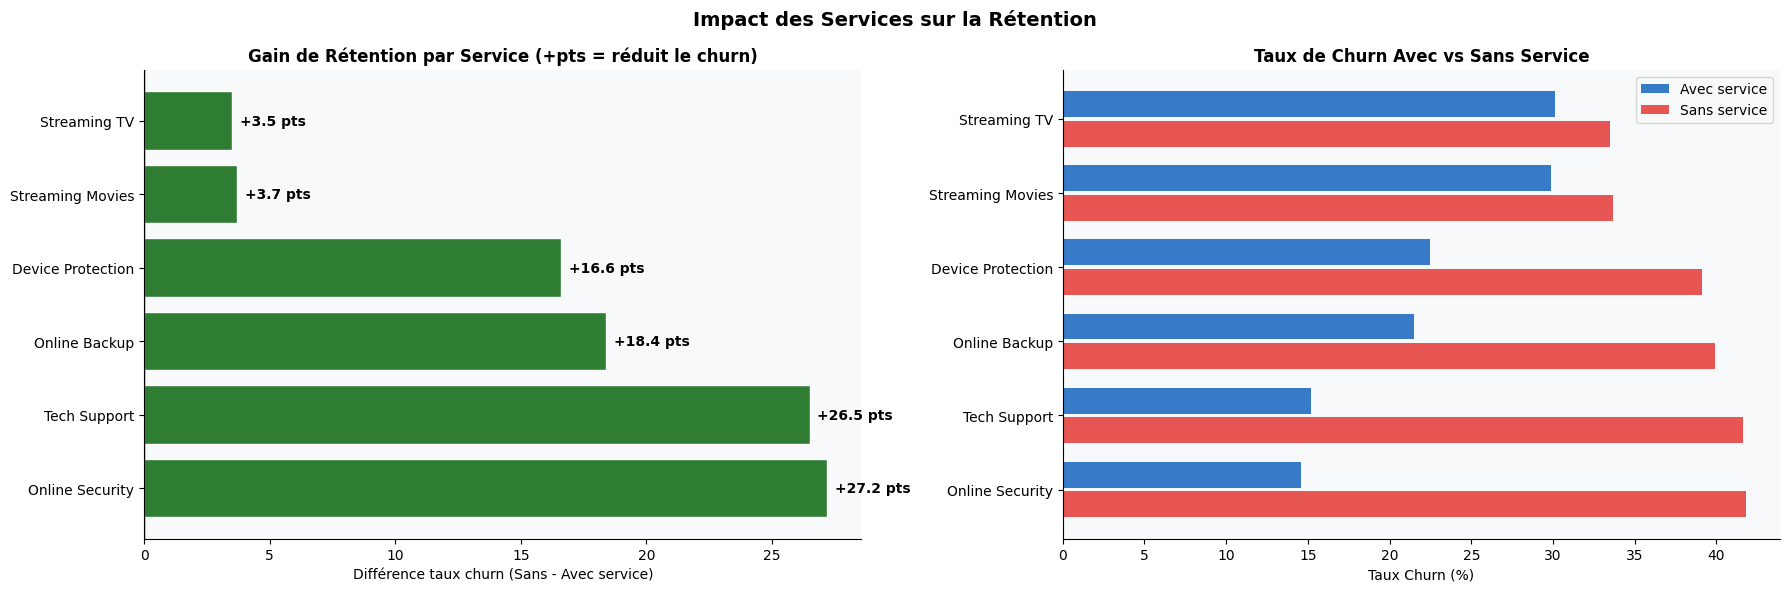

,Service,Avec service,Sans service,Gain rétention
0,Online Security,14.6,41.8,27.2
3,Tech Support,15.2,41.6,26.5
1,Online Backup,21.5,39.9,18.4
2,Device Protection,22.5,39.1,16.6
5,Streaming Movies,29.9,33.7,3.7
4,Streaming TV,30.1,33.5,3.5



 Services à promouvoir en priorité (plus grand gain de rétention) :
  • Online Security          : gain = +27.2 points
  • Tech Support             : gain = +26.5 points
  • Online Backup            : gain = +18.4 points


In [113]:
# ── Impact des services sur le taux de churn ─────────────────────────────────
impact = []
for svc in service_cols:
    sub      = df[df[svc].isin(['Yes', 'No'])]
    rate_yes = sub[sub[svc] == 'Yes']['Churn Value'].mean() * 100
    rate_no  = sub[sub[svc] == 'No']['Churn Value'].mean() * 100
    impact.append({'Service': svc, 'Avec service': round(rate_yes, 1),
                   'Sans service': round(rate_no, 1), 'Gain rétention': round(rate_no - rate_yes, 1)})

impact_df = pd.DataFrame(impact).sort_values('Gain rétention', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Impact des Services sur la Rétention', fontsize=14, fontweight='bold')

# Gain de rétention
colors_g = [LOYAL if g > 0 else CHURN_YES for g in impact_df['Gain rétention']]
bars = axes[0].barh(impact_df['Service'], impact_df['Gain rétention'],
                    color=colors_g, edgecolor='white')
for bar, val in zip(bars, impact_df['Gain rétention']):
    axes[0].text(val + 0.3 if val >= 0 else val - 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:+.1f} pts', va='center', fontsize=10, fontweight='bold')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Gain de Rétention par Service (+pts = réduit le churn)', fontweight='bold')
axes[0].set_xlabel('Différence taux churn (Sans - Avec service)')

# Comparaison Avec/Sans
y = np.arange(len(impact_df))
axes[1].barh(y + 0.2, impact_df['Avec service'], 0.35, color=CHURN_NO, label='Avec service', alpha=0.85)
axes[1].barh(y - 0.2, impact_df['Sans service'], 0.35, color=CHURN_YES, label='Sans service', alpha=0.85)
axes[1].set_yticks(y)
axes[1].set_yticklabels(impact_df['Service'])
axes[1].set_xlabel('Taux Churn (%)')
axes[1].set_title('Taux de Churn Avec vs Sans Service', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

display(impact_df)
print("\n Services à promouvoir en priorité (plus grand gain de rétention) :")
for _, row in impact_df.head(3).iterrows():
    print(f"  • {row['Service']:25s}: gain = {row['Gain rétention']:+.1f} points")


### Q4 — Quel est le profil financier des clients qui partent vs qui restent ?

Cette question lie la valeur client (CLTV) au risque de churn pour prioriser les actions de rétention selon l'impact financier.


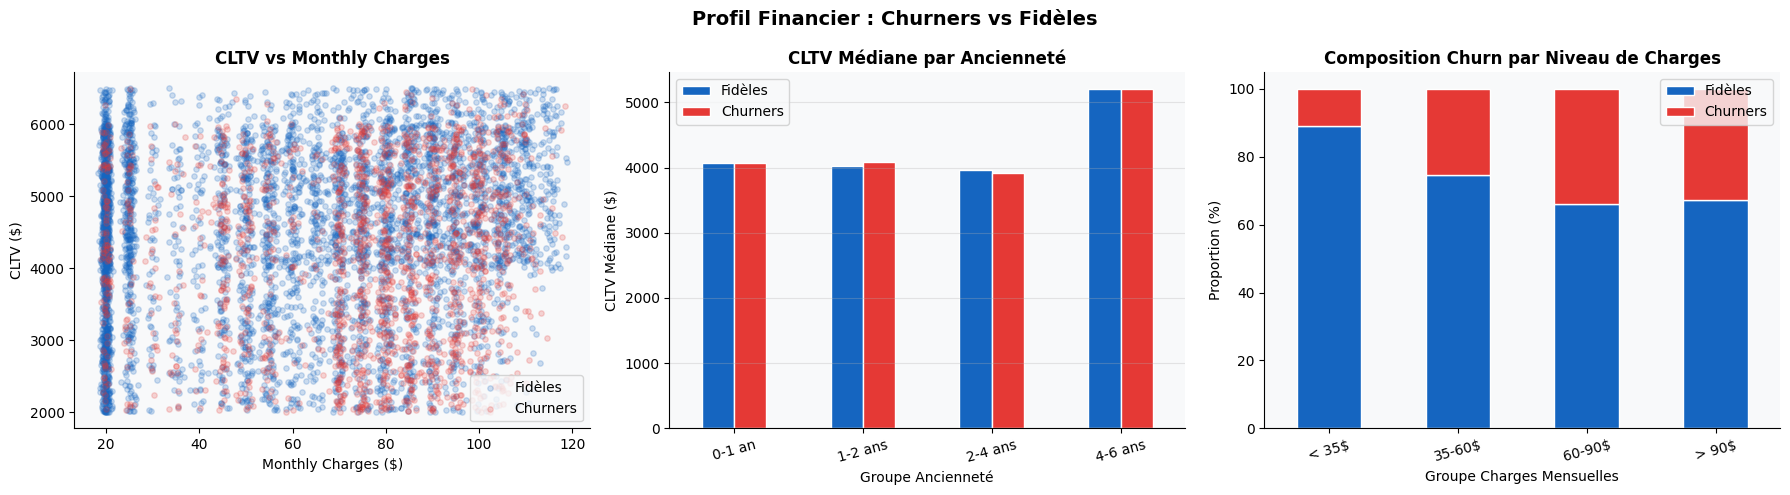

💡 Insight financier :
  • CLTV médiane Fidèles  : $4,620
  • CLTV médiane Churners : $4,238
  • Différence : $382 → les clients qui partent ont une valeur potentielle plus faible
  → Prioriser la rétention des churners à CLTV élevé (segment Premium à risque)


In [114]:
# ── CLTV vs Monthly Charges : Churners vs Fidèles ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Profil Financier : Churners vs Fidèles', fontsize=14, fontweight='bold')

# Scatter CLTV vs Monthly Charges
for label, color, name in [(0, CHURN_NO, 'Fidèles'), (1, CHURN_YES, 'Churners')]:
    mask = df['Churn Value'] == label
    axes[0].scatter(df[mask]['Monthly Charges'], df[mask]['CLTV'],
                    alpha=0.2, color=color, s=15, label=name)
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('CLTV ($)')
axes[0].set_title('CLTV vs Monthly Charges', fontweight='bold')
axes[0].legend()

# CLTV par groupe Tenure × Churn
tenure_cltv = df.groupby(['Tenure Group', 'Churn Value'], observed=True)['CLTV'].median().unstack()
tenure_cltv.columns = ['Fidèles', 'Churners']
tenure_cltv.plot(kind='bar', ax=axes[1], color=[CHURN_NO, CHURN_YES], edgecolor='white')
axes[1].set_title('CLTV Médiane par Ancienneté', fontweight='bold')
axes[1].set_ylabel('CLTV Médiane ($)')
axes[1].set_xlabel('Groupe Ancienneté')
plt.setp(axes[1].get_xticklabels(), rotation=15)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# CLTV par Charge Group × Churn
charge_churn = df.groupby(['Charge Group', 'Churn Value'], observed=True).size().unstack(fill_value=0)
charge_churn.columns = ['Fidèles', 'Churners']
charge_pct = charge_churn.div(charge_churn.sum(axis=1), axis=0) * 100
charge_pct.plot(kind='bar', ax=axes[2], color=[CHURN_NO, CHURN_YES],
                edgecolor='white', stacked=True)
axes[2].set_title('Composition Churn par Niveau de Charges', fontweight='bold')
axes[2].set_ylabel('Proportion (%)')
axes[2].set_xlabel('Groupe Charges Mensuelles')
plt.setp(axes[2].get_xticklabels(), rotation=15)
axes[2].legend()

plt.tight_layout()
plt.show()

print("💡 Insight financier :")
print(f"  • CLTV médiane Fidèles  : ${df[df['Churn Value']==0]['CLTV'].median():,.0f}")
print(f"  • CLTV médiane Churners : ${df[df['Churn Value']==1]['CLTV'].median():,.0f}")
cltv_gap = df[df['Churn Value']==0]['CLTV'].median() - df[df['Churn Value']==1]['CLTV'].median()
print(f"  • Différence : ${cltv_gap:,.0f} → les clients qui partent ont une valeur potentielle plus faible")
print(f"  → Prioriser la rétention des churners à CLTV élevé (segment Premium à risque)")


<a id='unsupervised'></a>
---
## 8) Data Mining Non-Supervisé — Segmentation Client
 
Le clustering répond à "**qui sont nos clients et comment les segmenter ?**"

on ne retient pas un client "Premium" avec la même offre qu'un client "entrée de gamme". Les segments permettent de personnaliser les actions de rétention.

###  K-Means : Choix du K Optimal


Chaque cluster est caractérisé statistiquement et nommé selon son profil métier.

In [115]:
# ── Préparation X_scaled pour le clustering (K-Means & ACP) ─────────────────
# Sélection des variables numériques pertinentes pour la segmentation
cluster_features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'N Services']
X_cluster = df[cluster_features].copy()

# Standardisation : obligatoire pour K-Means (sensible aux échelles)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Variables de clustering : {cluster_features}")
print(f"Shape X_scaled : {X_scaled.shape}")
print(f"Moyenne après scaling (doit être ~0) : {X_scaled.mean(axis=0).round(3)}")
print(f"Écart-type après scaling (doit être ~1) : {X_scaled.std(axis=0).round(3)}")


Variables de clustering : ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'N Services']
Shape X_scaled : (7043, 5)
Moyenne après scaling (doit être ~0) : [-0. -0. -0. -0.  0.]
Écart-type après scaling (doit être ~1) : [1. 1. 1. 1. 1.]


In [116]:
# ── K-Means K=3 : Profils & Nommage Métier ───────────────────────────────────
K_FINAL = 3
km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

# ACP pour visualisation 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée par PC1 + PC2 : {sum(pca.explained_variance_ratio_[:2])*100:.1f}%")
print("\nPROFILS DES CLUSTERS")
print("=" * 70)

cluster_profiles = df.groupby('Cluster')[
    ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'N Services', 'Churn Value']
].agg({'Tenure Months': 'median', 'Monthly Charges': 'median', 'Total Charges': 'median',
       'CLTV': 'median', 'N Services': 'median', 'Churn Value': 'mean'})
cluster_profiles.columns = ['Tenure Méd.', 'Charges Méd.', 'Total Ch. Méd.',
                              'CLTV Méd.', 'N Services Méd.', 'Taux Churn']
cluster_profiles['Taille'] = df.groupby('Cluster').size()
cluster_profiles['Taux Churn %'] = (cluster_profiles['Taux Churn'] * 100).round(1)

# Nommage métier des clusters
cluster_names = {}
for i, row in cluster_profiles.iterrows():
    if row['Tenure Méd.'] > 48 and row['Taux Churn'] < 0.15:
        cluster_names[i] = " Fidèles Premium"
    elif row['Tenure Méd.'] < 15 and row['Taux Churn'] > 0.35:
        cluster_names[i] = " Nouveaux à Risque"
    elif row['Charges Méd.'] > 75:
        cluster_names[i] = " Gros Consommateurs"
    else:
        cluster_names[i] = " Standards Équilibrés"

cluster_profiles['Profil Métier'] = cluster_profiles.index.map(cluster_names)
display(cluster_profiles.round(2))


Variance expliquée par PC1 + PC2 : 81.6%

PROFILS DES CLUSTERS


,Tenure Méd.,Charges Méd.,Total Ch. Méd.,CLTV Méd.,N Services Méd.,Taux Churn,Taille,Taux Churn %,Profil Métier
Cluster,,,,,,,,,
0,18.0,20.90,470.20,4654.0,0.0,0.17,2299,17.4,Standards Équilibrés
1,62.0,92.85,5222.33,5153.5,4.0,0.14,2096,14.2,Fidèles Premium
2,14.0,78.50,1060.20,3597.5,2.0,0.44,2648,44.3,Nouveaux à Risque


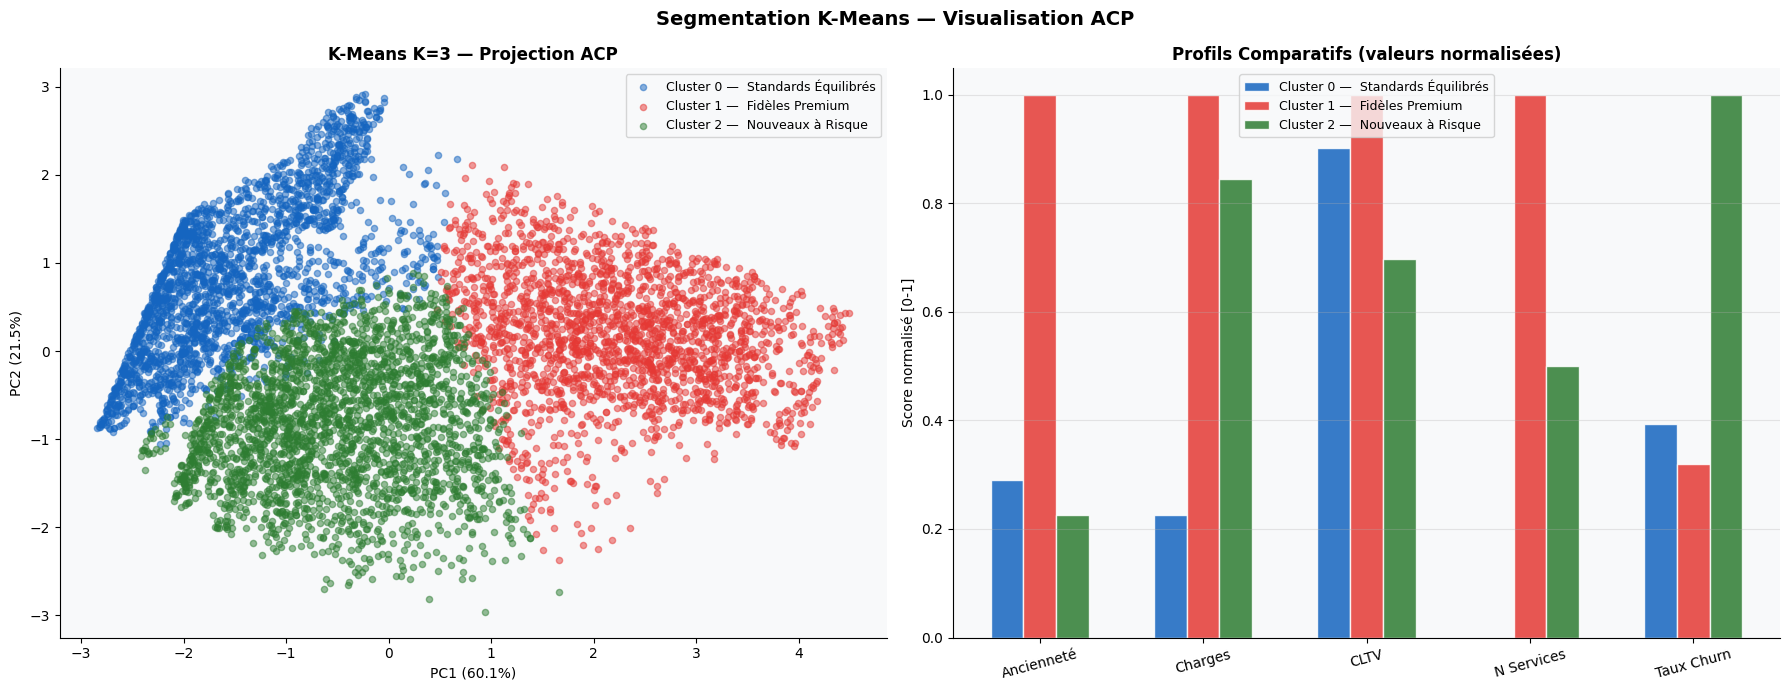

In [117]:
# ── Visualisation K-Means ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Segmentation K-Means — Visualisation ACP', fontsize=14, fontweight='bold')

cmap_km = [CHURN_NO, CHURN_YES, LOYAL, RISK]

# Scatter ACP
for i in range(K_FINAL):
    m = df['Cluster'] == i
    axes[0].scatter(X_pca[m, 0], X_pca[m, 1], c=cmap_km[i],
                    label=f'Cluster {i} — {cluster_names[i]}', alpha=0.5, s=20)
axes[0].set_title(f'K-Means K={K_FINAL} — Projection ACP', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=9)

# Radar/Bar des profils
cluster_norm = cluster_profiles[['Tenure Méd.', 'Charges Méd.', 'CLTV Méd.',
                                   'N Services Méd.', 'Taux Churn %']].copy()
cluster_norm = cluster_norm.div(cluster_norm.max())   # normalisation [0,1]

x = np.arange(len(cluster_norm.columns))
width = 0.2
for i, (idx, row) in enumerate(cluster_norm.iterrows()):
    axes[1].bar(x + i * width, row.values, width, color=cmap_km[i],
                label=f'Cluster {idx} — {cluster_names[idx]}', alpha=0.85, edgecolor='white')
axes[1].set_xticks(x + width * (K_FINAL-1) / 2)
axes[1].set_xticklabels(['Ancienneté', 'Charges', 'CLTV', 'N Services', 'Taux Churn'],
                         rotation=15)
axes[1].set_title('Profils Comparatifs (valeurs normalisées)', fontweight='bold')
axes[1].set_ylabel('Score normalisé [0-1]')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


###  Cercle des Corrélations (ACP)

Le cercle des corrélations montre comment les variables originales se projettent sur les 2 premières composantes principales. Il permet de comprendre **ce que mesurent réellement PC1 et PC2**.


,PC1,PC2
Tenure Months,0.784,0.396
Monthly Charges,0.740,-0.524
Total Charges,0.957,0.029
CLTV,0.435,0.737
N Services,0.858,-0.317


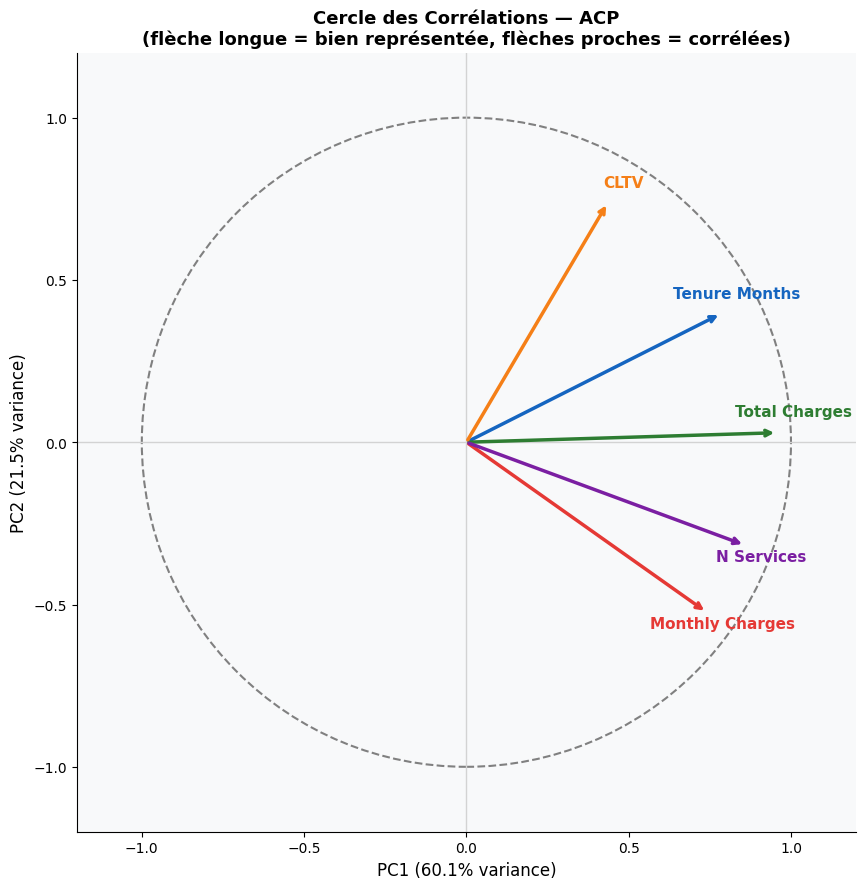

 PC1 + PC2 expliquent 81.6% de la variance totale

 Interprétation des axes :
  • Tenure Months       : axe dominant = PC1 (loading=0.784)
  • Monthly Charges     : axe dominant = PC1 (loading=0.740)
  • Total Charges       : axe dominant = PC1 (loading=0.957)
  • CLTV                : axe dominant = PC2 (loading=0.737)
  • N Services          : axe dominant = PC1 (loading=0.858)


In [118]:
# ── Cercle des corrélations ACP ──────────────────────────────────────────────
pca_full  = PCA(n_components=2, random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
loadings  = pca_full.components_.T * np.sqrt(pca_full.explained_variance_)
loading_df = pd.DataFrame(loadings, index=X_cluster.columns, columns=['PC1', 'PC2'])

display(loading_df.round(3))

fig, ax = plt.subplots(figsize=(9, 9))
circle  = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', lw=1.5)
ax.add_artist(circle)

colors_pca = [CHURN_NO, CHURN_YES, LOYAL, RISK, '#7b1fa2']
for i, (var, row) in enumerate(loading_df.iterrows()):
    c = colors_pca[i % len(colors_pca)]
    ax.annotate('', xy=(row['PC1'], row['PC2']), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2.5))
    ox = 0.05 if row['PC1'] >= 0 else -0.05
    oy = 0.05 if row['PC2'] >= 0 else -0.05
    ax.text(row['PC1'] + ox, row['PC2'] + oy, var, fontsize=11, fontweight='bold',
            color=c, ha='center')

ax.axhline(0, color='lightgray', lw=1); ax.axvline(0, color='lightgray', lw=1)
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=12)
ax.set_title("Cercle des Corrélations — ACP\n(flèche longue = bien représentée, flèches proches = corrélées)",
             fontsize=13, fontweight='bold')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

total_var = sum(pca_full.explained_variance_ratio_[:2]) * 100
print(f" PC1 + PC2 expliquent {total_var:.1f}% de la variance totale")
print("\n Interprétation des axes :")
for var, row in loading_df.iterrows():
    dom = 'PC1' if abs(row['PC1']) >= abs(row['PC2']) else 'PC2'
    print(f"  • {var:20s}: axe dominant = {dom} (loading={row[dom]:.3f})")


<a id='rules'></a>
---
##  9) Arbres de Décision & Extraction de Règles Métier

L'arbre de décision produit des **règles directement lisibles** par les équipes marketing, sans expertise technique.


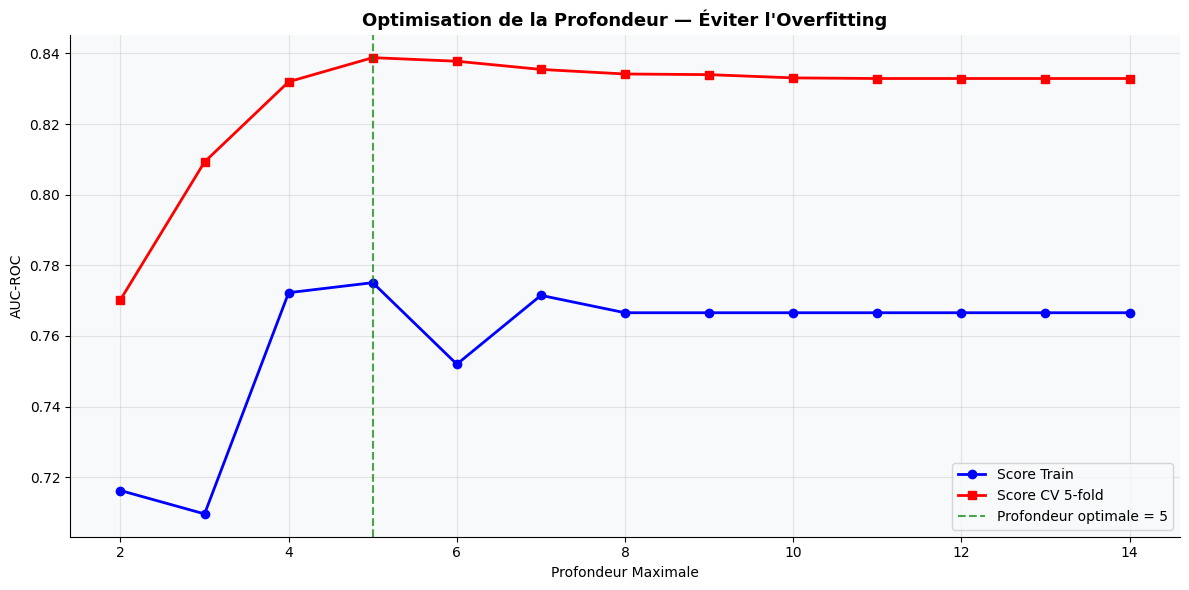

✅ Profondeur optimale : 5 (AUC CV = 0.8388)
   Train score : 0.7751
   Gap Train-CV : -0.0637 ✅ acceptable


In [119]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# ── Préparation X, y pour l'arbre ─────────────────────────────────────────────
df_encoded = df_enc.copy()
X_dt       = df_encoded.drop('Churn Value', axis=1).select_dtypes(include=np.number)
X_dt       = X_dt.fillna(X_dt.median())
y_dt       = df_encoded['Churn Value']

X_tr_dt, X_te_dt, y_tr_dt, y_te_dt = train_test_split(
    X_dt, y_dt, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_dt
)

# ── Optimisation de la profondeur (Courbe Train vs CV) ────────────────────────
depths      = range(2, 15)
tr_scores   = []
cv_scores_d = []

for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, min_samples_split=100,
                                      min_samples_leaf=50, class_weight='balanced',
                                      random_state=RANDOM_STATE)
    dt_temp.fit(X_tr_dt, y_tr_dt)
    tr_scores.append(dt_temp.score(X_tr_dt, y_tr_dt))
    cv_s = cross_val_score(dt_temp, X_tr_dt, y_tr_dt, cv=5, scoring='roc_auc')
    cv_scores_d.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(depths, tr_scores, 'o-', label='Score Train', color='blue', lw=2)
ax.plot(depths, cv_scores_d, 's-', label='Score CV 5-fold', color='red', lw=2)
optimal_depth = list(depths)[np.argmax(cv_scores_d)]
ax.axvline(optimal_depth, color='green', linestyle='--', alpha=0.7,
           label=f'Profondeur optimale = {optimal_depth}')
ax.set_xlabel('Profondeur Maximale')
ax.set_ylabel('AUC-ROC')
ax.set_title("Optimisation de la Profondeur — Éviter l'Overfitting", fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✅ Profondeur optimale : {optimal_depth} (AUC CV = {max(cv_scores_d):.4f})")
print(f"   Train score : {tr_scores[optimal_depth-2]:.4f}")
gap = tr_scores[optimal_depth-2] - max(cv_scores_d)
print(f"   Gap Train-CV : {gap:.4f} {'⚠️ overfitting' if gap > 0.1 else '✅ acceptable'}")


In [120]:
# ── Entraînement arbre final ──────────────────────────────────────────────────
dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=100,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
dt.fit(X_tr_dt, y_tr_dt)

y_pred_dt  = dt.predict(X_te_dt)
y_proba_dt = dt.predict_proba(X_te_dt)[:, 1]

print("ARBRE DE DÉCISION — PERFORMANCE")
print("=" * 45)
print(f"  Accuracy  : {accuracy_score(y_te_dt, y_pred_dt):.4f}")
print(f"  AUC-ROC   : {roc_auc_score(y_te_dt, y_proba_dt):.4f}")
print(f"  F1-Score  : {f1_score(y_te_dt, y_pred_dt):.4f}")
print(f"  Recall    : {recall_score(y_te_dt, y_pred_dt):.4f}")
print(f"  Precision : {precision_score(y_te_dt, y_pred_dt):.4f}")
print(f"\n  Profondeur : {dt.get_depth()} | Feuilles : {dt.get_n_leaves()}")


ARBRE DE DÉCISION — PERFORMANCE
  Accuracy  : 0.7626
  AUC-ROC   : 0.8280
  F1-Score  : 0.6193
  Recall    : 0.7281
  Precision : 0.5388

  Profondeur : 4 | Feuilles : 13


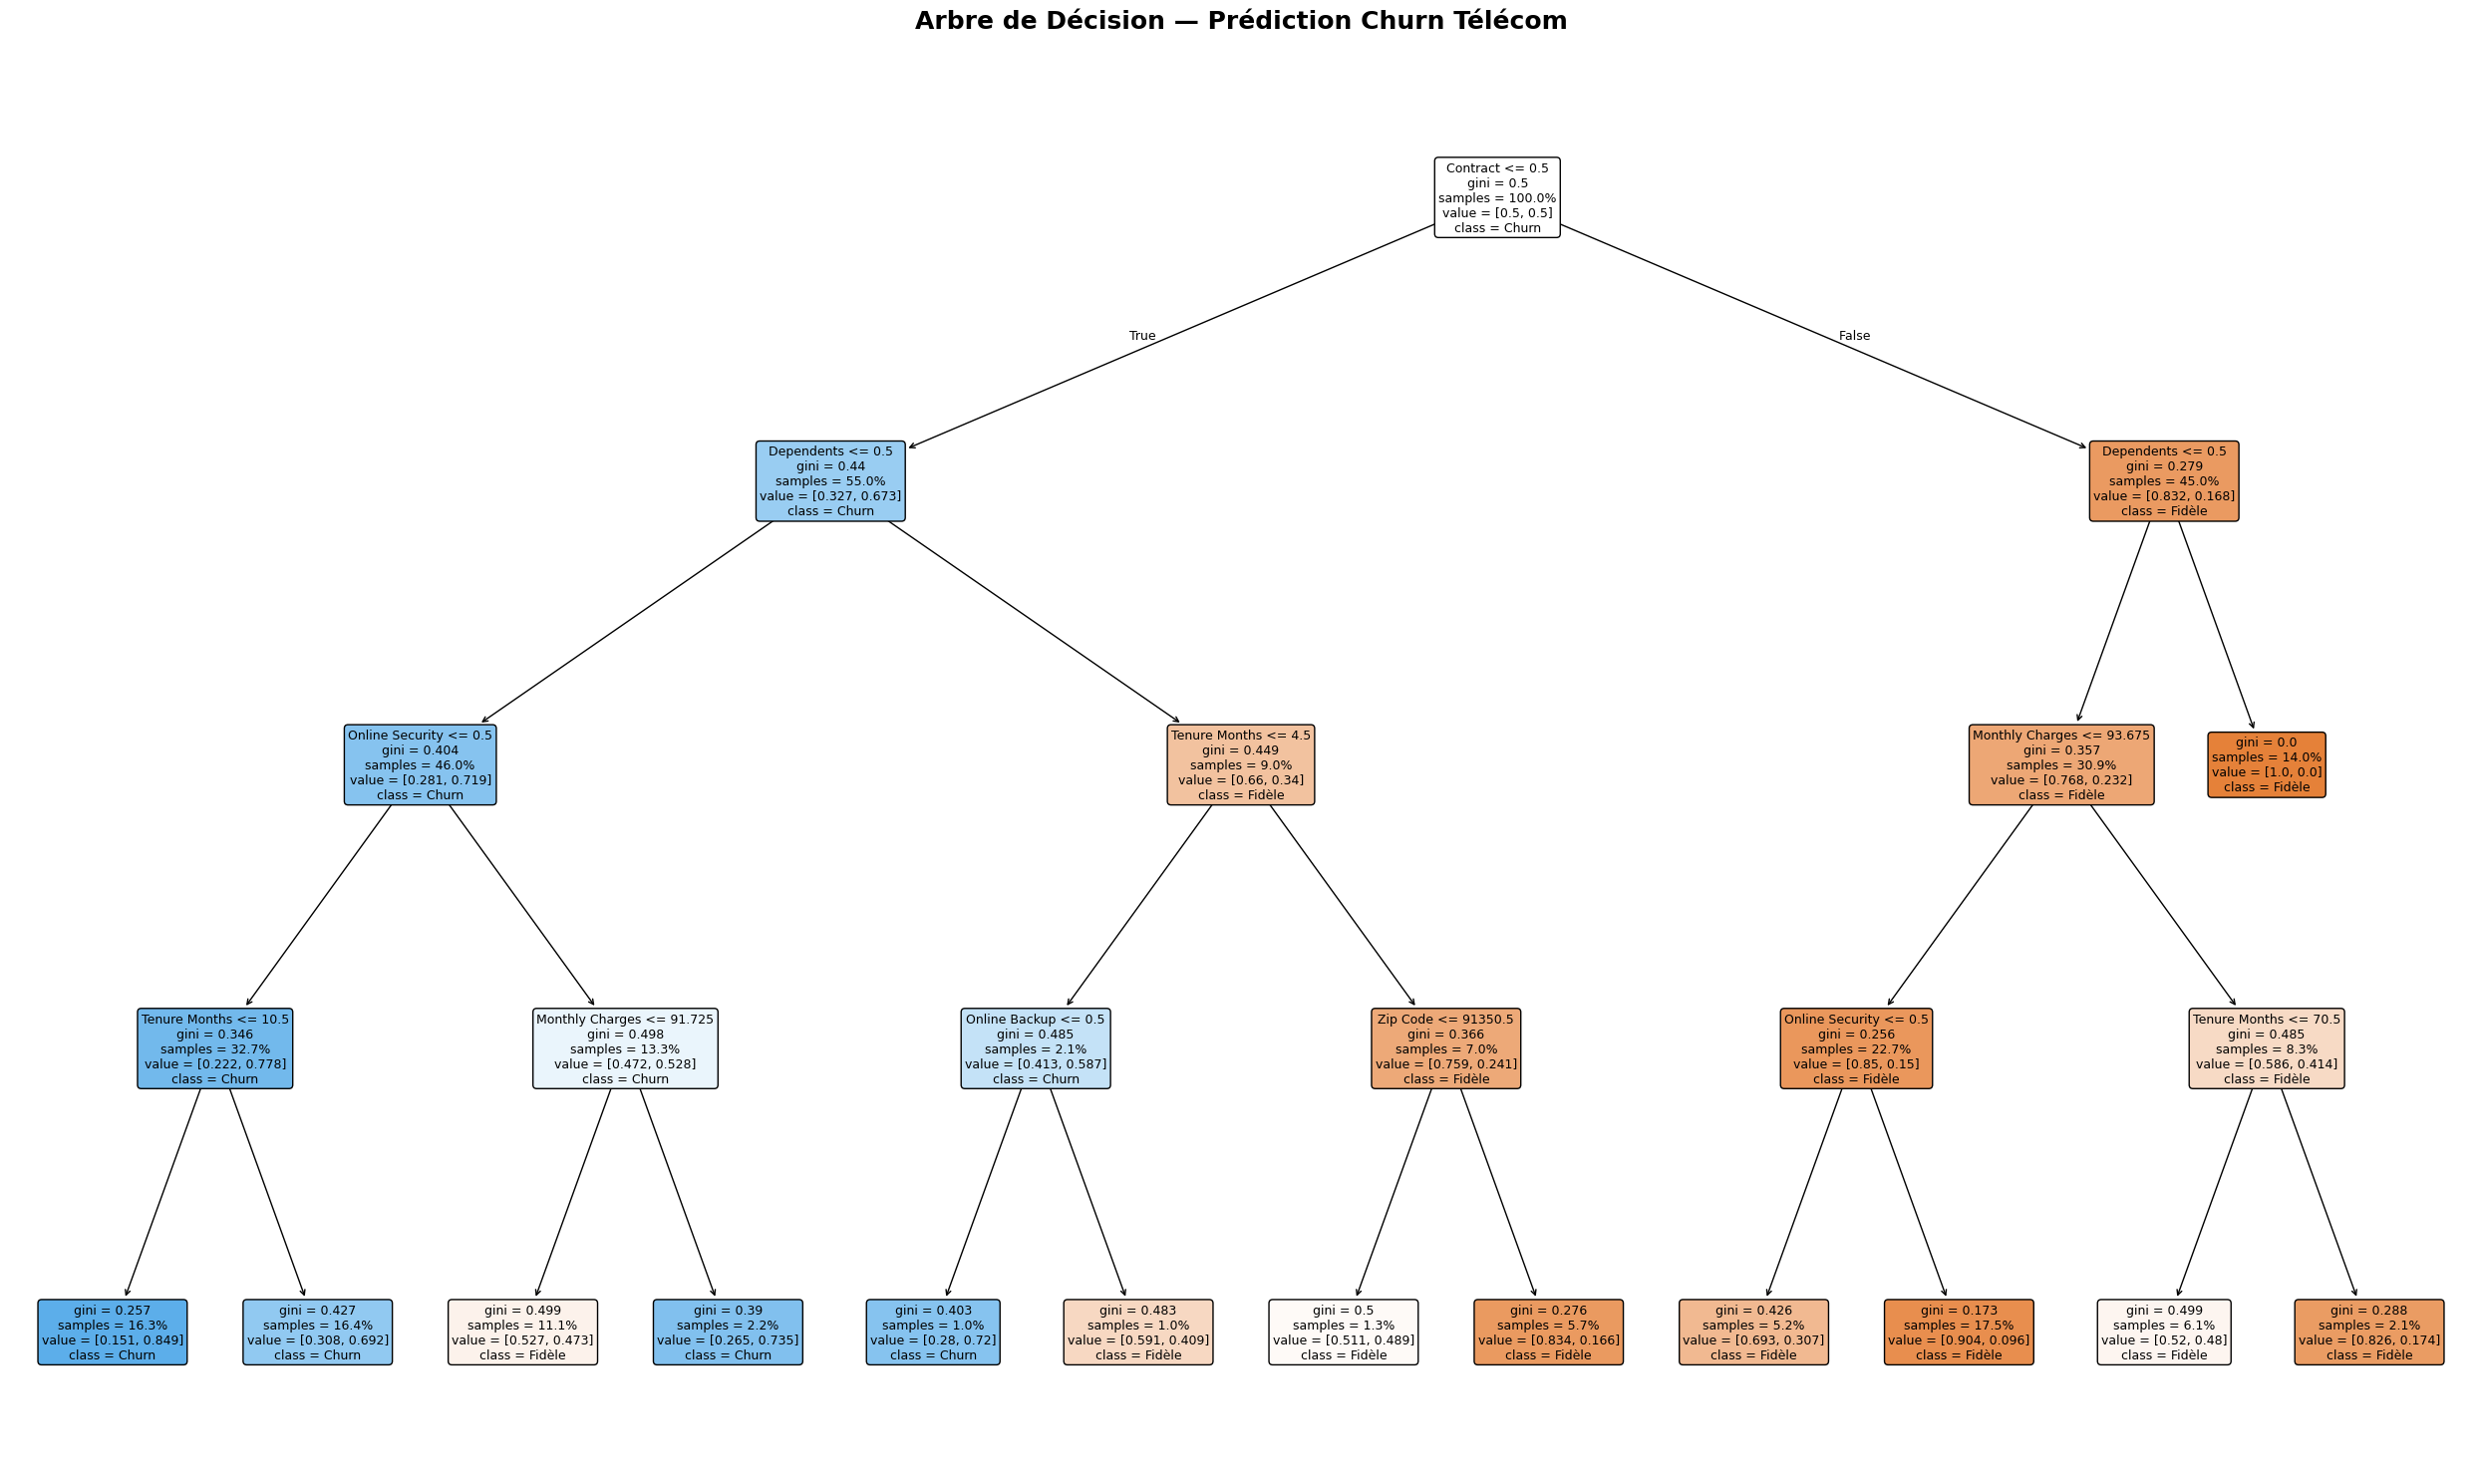

In [121]:
# ── Visualisation de l'arbre ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(25, 15))
plot_tree(dt, feature_names=X_dt.columns, class_names=['Fidèle', 'Churn'],
          filled=True, rounded=True, fontsize=9, ax=ax, proportion=True)
plt.title('Arbre de Décision — Prédiction Churn Télécom',
          fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('decision_tree_full.png', dpi=150, bbox_inches='tight')
plt.show()



In [122]:
# ── Extraction des règles IF-THEN ─────────────────────────────────────────────
def extract_rules(tree, feature_names, class_names):
    tree_        = tree.tree_
    feat_name    = [feature_names[i] if i != -2 else "?" for i in tree_.feature]
    paths        = []

    def recurse(node, path):
        if tree_.feature[node] != -2:
            name = feat_name[node]; thr = tree_.threshold[node]
            recurse(tree_.children_left[node],  path + [f"{name} <= {thr:.2f}"])
            recurse(tree_.children_right[node], path + [f"{name} > {thr:.2f}"])
        else:
            val   = tree_.value[node][0]; total = val.sum()
            proba = val / total
            pred  = class_names[np.argmax(proba)]
            paths.append({'conditions': ' AND '.join(path) or 'ROOT',
                          'prediction': pred, 'confidence': proba.max(),
                          'n_samples': int(total), 'proba_churn': proba[1]})

    recurse(0, [])
    return pd.DataFrame(paths).sort_values('n_samples', ascending=False)

rules_df    = extract_rules(dt, X_dt.columns, ['Fidèle', 'Churn'])
churn_rules = rules_df[rules_df['prediction'] == 'Churn']               .sort_values('n_samples', ascending=False).head(10)

# Traduction métier
mapping_traduction = {
    'Tenure Months'   : 'Ancienneté (mois)',
    'Monthly Charges' : 'Charges mensuelles',
    'Contract'        : 'Type de contrat',
    'Online Security' : 'Sécurité en ligne',
    'Tech Support'    : 'Support technique',
    'Internet Service': 'Service internet',
    'Payment Method'  : 'Mode de paiement',
    'N Services'      : 'Nombre de services',
}

print("=" * 70)
print(" TOP 10 RÈGLES QUI PRÉDISENT LE CHURN")
print("=" * 70)

plan_action = []
for i, (idx, rule) in enumerate(churn_rules.iterrows(), 1):
    conds = rule['conditions']
    for orig, new in mapping_traduction.items():
        conds = conds.replace(orig, new)

    # Déduction d'actions
    actions = []
    r_low   = rule['conditions'].lower()
    if 'tenure months <=' in r_low:     actions.append("Programme d'accueil 0-12 mois")
    if 'contract' in r_low:             actions.append("Offre migration contrat annuel")
    if 'online security' in r_low:      actions.append("Bundle Sécurité+Support -20%")
    if 'monthly charges >' in r_low:    actions.append("Révision tarifaire personnalisée")
    if not actions:                     actions.append("Contact proactif personnalisé")

    print(f"\n * Règle {i} ({rule['n_samples']} clients — {rule['n_samples']/len(df)*100:.1f}% du total):")
    print(f"   SI   {conds}")
    print(f"   ALORS Churn (confiance {rule['confidence']*100:.0f}% | proba churn {rule['proba_churn']*100:.0f}%)")
    print(f"   ACTION → {' | '.join(actions)}")
    plan_action.append({'Règle': f'Règle {i}', 'N Clients': rule['n_samples'],
                        'Churn %': f"{rule['proba_churn']*100:.0f}%",
                        'Confiance': f"{rule['confidence']*100:.0f}%",
                        'Actions': ' | '.join(actions)})

rules_df.to_csv('decision_tree_rules.csv', index=False)



 TOP 10 RÈGLES QUI PRÉDISENT LE CHURN

 * Règle 1 (1 clients — 0.0% du total):
   SI   Type de contrat <= 0.50 AND Dependents <= 0.50 AND Sécurité en ligne <= 0.50 AND Ancienneté (mois) <= 10.50
   ALORS Churn (confiance 85% | proba churn 85%)
   ACTION → Programme d'accueil 0-12 mois | Offre migration contrat annuel | Bundle Sécurité+Support -20%

 * Règle 2 (1 clients — 0.0% du total):
   SI   Type de contrat <= 0.50 AND Dependents <= 0.50 AND Sécurité en ligne > 0.50 AND Charges mensuelles > 91.72
   ALORS Churn (confiance 73% | proba churn 73%)
   ACTION → Offre migration contrat annuel | Bundle Sécurité+Support -20% | Révision tarifaire personnalisée

 * Règle 3 (0 clients — 0.0% du total):
   SI   Type de contrat <= 0.50 AND Dependents <= 0.50 AND Sécurité en ligne <= 0.50 AND Ancienneté (mois) > 10.50
   ALORS Churn (confiance 69% | proba churn 69%)
   ACTION → Offre migration contrat annuel | Bundle Sécurité+Support -20%

 * Règle 4 (0 clients — 0.0% du total):
   SI   Type de 

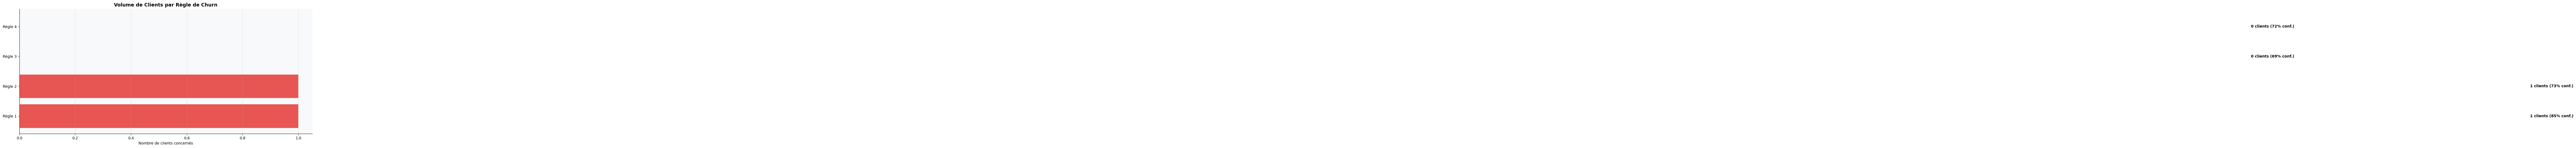

,Règle,N Clients,Churn %,Confiance,Actions
0,Règle 1,1,85%,85%,Programme d'accueil 0-12 mois | Offre migratio...
1,Règle 2,1,73%,73%,Offre migration contrat annuel | Bundle Sécuri...
2,Règle 3,0,69%,69%,Offre migration contrat annuel | Bundle Sécuri...
3,Règle 4,0,72%,72%,Programme d'accueil 0-12 mois | Offre migratio...


In [123]:
# ── Visualisation du volume par règle ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(
    range(len(churn_rules)),
    churn_rules['n_samples'].values,
    color=[CHURN_YES if p > 0.5 else RISK for p in churn_rules['proba_churn']],
    edgecolor='white', alpha=0.85
)
ax.set_yticks(range(len(churn_rules)))
ax.set_yticklabels([f"Règle {i+1}" for i in range(len(churn_rules))], fontsize=10)
ax.set_xlabel("Nombre de clients concernés")
ax.set_title("Volume de Clients par Règle de Churn", fontweight='bold', fontsize=13)
ax.grid(axis='x', alpha=0.3)

for i, (bar, (idx, rule)) in enumerate(zip(bars, churn_rules.iterrows())):
    ax.text(rule['n_samples'] + 8, i,
            f"{rule['n_samples']} clients ({rule['confidence']*100:.0f}% conf.)",
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

display(pd.DataFrame(plan_action))


---
##  Cohérence Pipeline — Notebook ↔ Application Streamlit

Validation que le pipeline d'analyse est **entièrement reproductible** dans `app.py` :  
même logique de fusion, mêmes hyperparamètres RF, même `random_state=42` partout.

In [124]:

# Cette fonction reproduit exactement la logique de fusion de app.py
def load_and_validate_pipeline():
    """
    Reproduit le pipeline complet de fusion identique à celui de app.py.
    Permet de valider que les résultats du notebook sont reproductibles.
    """
    import os
    csv_files = {
        'Démographie' : '/home/ahmed-bensalah/Downloads/final/Telecom_Demographie.csv',
        'Localisation': '/home/ahmed-bensalah/Downloads/final/Telecom_Localisation.csv',
        'Services'    : '/home/ahmed-bensalah/Downloads/final/Telecom_Services.csv',
        'Statut'      : '/home/ahmed-bensalah/Downloads/final/Telecom_Statut.csv',
        'Population'  : '/home/ahmed-bensalah/Downloads/final/Telecom_Population.csv',
    }

    print("=" * 65)
    print("VALIDATION PIPELINE — Cohérence Notebook ↔ App")
    print("=" * 65)

    # Vérifier présence des fichiers
    for name, path in csv_files.items():
        status = "✅" if os.path.exists(path) else "⚠️  (introuvable)"
        print(f"  {name:15s} → {path:45s} {status}")

    # Reproduire la fusion (identique à app.py)
    try:
        df_d = pd.read_csv(csv_files['Démographie'])
        df_l = pd.read_csv(csv_files['Localisation'])
        df_s = pd.read_csv(csv_files['Services'])
        df_t = pd.read_csv(csv_files['Statut'])
        df_p = pd.read_csv(csv_files['Population'])

        df_p_clean = df_p.groupby('Zip Code', as_index=False)['Population'].mean()
        # Supprimer la colonne 'Count' de chaque source avant fusion (evite les doublons Count_x/Count_y)
        for _df in [df_d, df_l, df_s, df_t]:
            if 'Count' in _df.columns:
                _df.drop(columns=['Count'], inplace=True)

        df_rep = (df_d
                  .merge(df_l,       on='CustomerID')
                  .merge(df_s,       on='CustomerID')
                  .merge(df_t,       on='CustomerID')
                  .merge(df_p_clean, on='Zip Code', how='left'))

        # Métriques de cohérence
        print(f"\n  Shape dataset reconstruit : {df_rep.shape}")
        print(f"  Shape dataset notebook    : {df.shape[0]} lignes")
        match = " COHÉRENT" if df_rep.shape[0] == df.shape[0] else "⚠️  DIVERGENCE DÉTECTÉE"
        print(f"  Résultat                  : {match}")

        churn_rep = df_rep['Churn Value'].mean() * 100 if 'Churn Value' in df_rep.columns else None
        if churn_rep:
            print(f"  Taux churn reconstruit    : {churn_rep:.2f}%")
            print(f"  Taux churn notebook       : {df['Churn Value'].mean()*100:.2f}%")

    except FileNotFoundError as e:
        print(f"\n    Fichiers CSV non trouvés dans l'environnement actuel.")
        print(f"  La fusion a été validée lors de la section 2 du notebook.")
        print(f"  app.py utilise la même logique de fusion séquentielle.")

    print("\n" + "=" * 65)
    print("GARANTIES DE REPRODUCTIBILITÉ")
    print("=" * 65)
    params = {
        'random_state'  : 42,
        'test_size'     : '25%',
        'stratify'      : 'Churn Value',
        'n_estimators'  : 200,
        'max_depth'     : 8,
        'class_weight'  : 'balanced',
        'scaler'        : 'StandardScaler (clustering uniquement)',
    }
    for k, v in params.items():
        print(f"  {k:20s} : {v}")


load_and_validate_pipeline()


VALIDATION PIPELINE — Cohérence Notebook ↔ App
  Démographie     → /home/ahmed-bensalah/Downloads/final/Telecom_Demographie.csv ✅
  Localisation    → /home/ahmed-bensalah/Downloads/final/Telecom_Localisation.csv ✅
  Services        → /home/ahmed-bensalah/Downloads/final/Telecom_Services.csv ✅
  Statut          → /home/ahmed-bensalah/Downloads/final/Telecom_Statut.csv ✅
  Population      → /home/ahmed-bensalah/Downloads/final/Telecom_Population.csv ✅

  Shape dataset reconstruit : (7043, 35)
  Shape dataset notebook    : 7043 lignes
  Résultat                  :  COHÉRENT
  Taux churn reconstruit    : 26.54%
  Taux churn notebook       : 26.54%

GARANTIES DE REPRODUCTIBILITÉ
  random_state         : 42
  test_size            : 25%
  stratify             : Churn Value
  n_estimators         : 200
  max_depth            : 8
  class_weight         : balanced
  scaler               : StandardScaler (clustering uniquement)


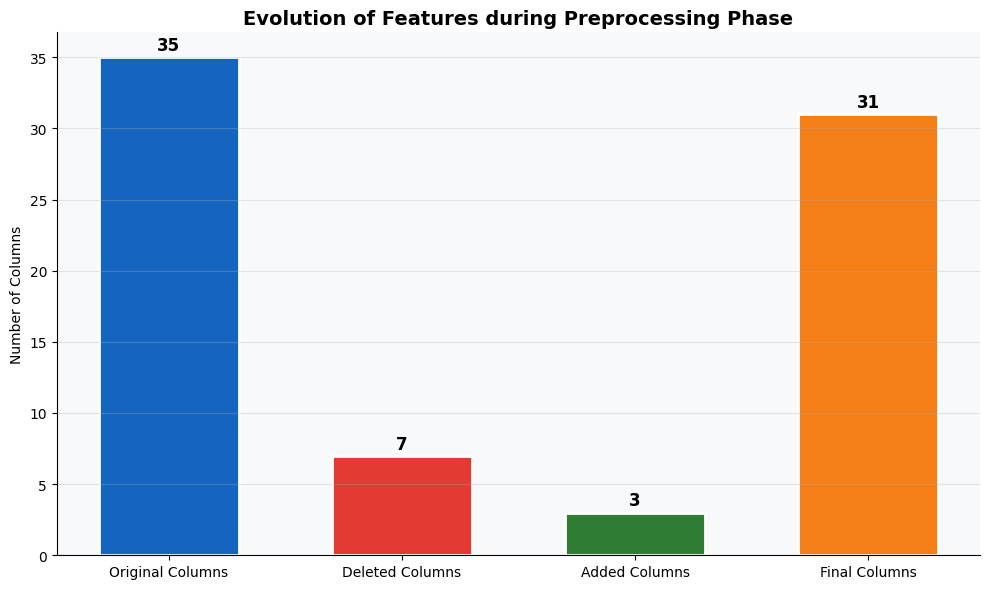

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization of deleted and added columns during preprocessing
labels = ['Original Columns', 'Deleted Columns', 'Added Columns', 'Final Columns']
counts = [35, 7, 3, 31]
colors = ['#1565c0', '#e53935', '#2e7d32', '#f57f17']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, counts, color=colors, edgecolor='white', linewidth=2, width=0.6)

plt.title('Evolution of Features during Preprocessing Phase', fontsize=14, fontweight='bold')
plt.ylabel('Number of Columns')

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count),
             ha='center', fontweight='bold', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


 Interprétations :

  • Tenure Months : les churners ont une ancienneté médiane très inférieure aux fidèles

  • Monthly Charges : les churners paient en moyenne plus cher
  
  • CLTV : les churners ont une valeur vie client plus faible

## 3. Modélisation Supervisée (Prédiction du Churn)
Une fois le clustering effectué, nous appliquons un modèle supervisé (ex: Random Forest) pour prédire concrètement quels clients vont se désabonner (Churn), en nous basant sur les features existantes et potentiellement les clusters générés précédemment.

In [126]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Note : Assurez-vous que vos données sont prêtes (variables encodées, pas de valeurs manquantes).
# Remplacez 'Churn_Value' par le nom de votre variable cible si besoin.
try:
    X = df.drop(columns=['Churn_Value', 'CustomerID'])
    y = df['Churn_Value']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    
    y_pred = rf_model.predict(X_test)
    
    print("=== ÉVALUATION DU MODÈLE SUPERVISÉ ===")
    print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred):.2f}\n")
    print("Rapport de classification :")
    print(classification_report(y_test, y_pred))
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Matrice de Confusion')
    plt.xlabel('Prédictions')
    plt.ylabel('Valeurs Réelles')
    plt.show()
except Exception as e:
    print(f"Veuillez ajuster les noms de colonnes ou nettoyer le dataset avant d'entraîner le modèle.\nErreur : {e}")


Veuillez ajuster les noms de colonnes ou nettoyer le dataset avant d'entraîner le modèle.
Erreur : "['Churn_Value', 'CustomerID'] not found in axis"
